In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
%matplotlib inline

# Load of dataframe 

In [2]:
#Function that converts weekday number into weekday name 

def weekday_word(weekday):
    if weekday==0:
        return "Monday"
    elif weekday==1:
        return "Tuesday"
    elif weekday==2:
        return "Wednesday"
    elif weekday==3:
        return "Thursday"
    elif weekday==4:
        return "Friday"
    elif weekday==5:
        return "Saturday"
    else:
        return "Sunday"

#Function tha flag if day of the week is weekend
def is_weekend(weekday):
    return weekday in [5,6]

test_start = pd.Timestamp("2018-11-01")
test_end   = pd.Timestamp("2019-01-01")

### Feature Explanation
- User Type: 
    - Customer = 24-hour pass or 3-day pass
    - Subscriber = Annual Member
- Gender:
    - 0 -> Unknown
    - 1 -> Male
    - 2 -> Female

In [3]:
# Load file 
f=pd.read_csv(r"Trips_2018.csv")

In [4]:
# See file 
f.describe()

,Unnamed: 0,tripduration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender
count,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07
mean,8.774169e+06,9.887432e+02,1.589282e+03,4.073737e+01,-7.398260e+01,1.580830e+03,4.073704e+01,-7.398281e+01,2.656141e+04,1.978993e+03,1.148613e+00
std,5.065769e+06,1.889584e+04,1.439432e+03,3.225813e-02,1.912753e-02,1.438502e+03,3.206583e-02,1.919611e-02,6.222916e+03,1.192922e+01,5.438043e-01
min,0.000000e+00,6.100000e+01,7.200000e+01,4.064654e+01,-7.402535e+01,7.200000e+01,4.064654e+01,-7.408364e+01,1.452900e+04,1.885000e+03,0.000000e+00
25%,4.387084e+06,3.580000e+02,3.800000e+02,4.071755e+01,-7.399521e+01,3.800000e+02,4.071755e+01,-7.399595e+01,2.029300e+04,1.969000e+03,1.000000e+00
50%,8.774169e+06,6.050000e+02,5.050000e+02,4.073818e+01,-7.398565e+01,5.050000e+02,4.073756e+01,-7.398602e+01,2.827000e+04,1.981000e+03,1.000000e+00
75%,1.316125e+07,1.060000e+03,3.249000e+03,4.075763e+01,-7.397283e+01,3.249000e+03,4.075725e+01,-7.397344e+01,3.185200e+04,1.989000e+03,1.000000e+00
max,1.754834e+07,1.951005e+07,3.721000e+03,4.550636e+01,-7.356891e+01,3.721000e+03,4.550636e+01,-7.356891e+01,3.583100e+04,2.002000e+03,2.000000e+00


In [5]:
# Set index to trip ID
f= f.rename({"Unnamed: 0": "Trip ID"}, axis="columns")
f = f.set_index("Trip ID")

In [6]:
# See file 
f.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender
Trip ID,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.4340,2018-01-01 14:07:08.1860,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1
1,723,2018-01-01 15:33:30.1820,2018-01-01 15:45:33.3410,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1
2,496,2018-01-01 15:39:18.3370,2018-01-01 15:47:35.1720,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1
3,306,2018-01-01 15:40:13.3720,2018-01-01 15:45:20.1910,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1
4,306,2018-01-01 18:14:51.5680,2018-01-01 18:19:57.6420,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1


In [7]:
# Convert starttime and stoptime to datetime object 
f['starttime'] = pd.to_datetime(f['starttime'], format='%Y-%m-%d %H:%M:%S.%f')
f['stoptime'] = pd.to_datetime(f['stoptime'], format='%Y-%m-%d %H:%M:%S.%f')

# Add the binary varible determining if the day of the week is weekend
f['weekday']= f['starttime'].dt.weekday
f['is_weekend']=[is_weekend(el) for el in f['weekday']]

In [8]:
#Check if the conversion to datetime is correct
f.dtypes

tripduration                        int64
starttime                  datetime64[ns]
stoptime                   datetime64[ns]
start_station_id                  float64
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_latitude              float64
end_station_longitude             float64
bikeid                              int64
usertype                           object
birth_year                          int64
gender                              int64
weekday                             int32
is_weekend                           bool
dtype: object

# Investigating the longitude and latitude coordinates of all bike stations

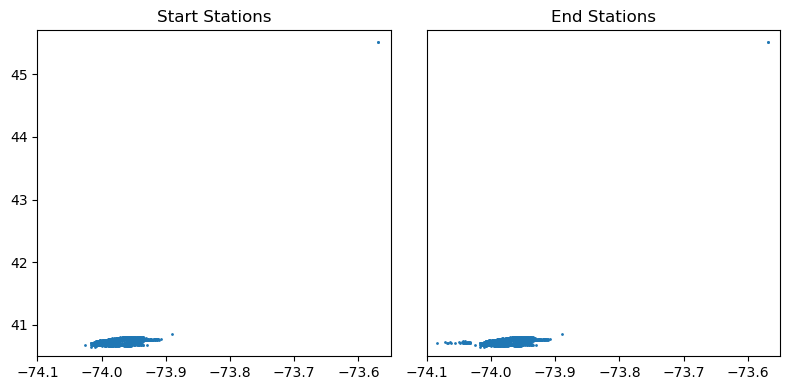

In [9]:

# Plot of the bikestation given there longitude and #Latitude coordinates (Both start and end stations)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.55), (40.5, 45.7)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

## Understanding the outlier

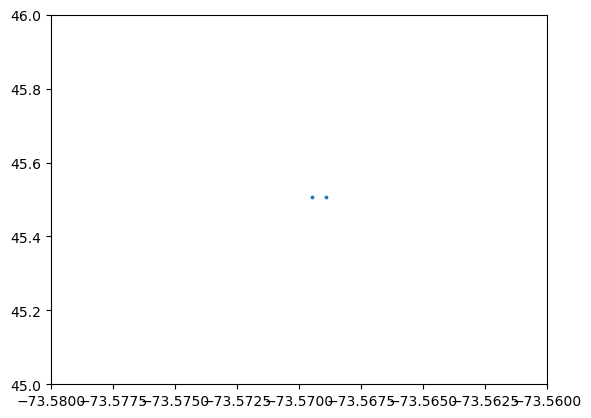

In [10]:
#Visualise outlier stations 
plt.scatter(start_station_df['longitude'], start_station_df['latitude'], s=3)
plt.xlim((-73.58, -73.56))
plt.ylim((45, 46))
plt.show()

### Investigate the outliers further

In [11]:
start_station_df[start_station_df.longitude > -73.6]

,latitude,longitude
start_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [12]:
end_station_df[end_station_df.longitude > -73.6]

,latitude,longitude
end_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [13]:
f[
    (f.start_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [14]:
f[
    (f.end_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,
8772457,1634200,2018-07-18 18:27:51.511,2018-08-06 16:24:32.388,3036.0,40.662908,-73.999722,3488.0,45.506364,-73.569463,24354,Subscriber,1988,1,2,False


In [15]:
f[
    (f.start_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [16]:
f[
    (f.end_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [17]:
f[
    (f.start_station_id == 3488) | (f.end_station_id == 3488) |
    (f.start_station_id == 3650) | (f.end_station_id == 3650)
].describe()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender,weekday
count,8.200000e+01,82,82,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2.954804e+04,2018-03-14 21:46:53.854036736,2018-03-15 05:59:22.416878080,3636.585366,45.447203,-73.574180,3642.097561,45.506269,-73.568933,23651.158537,1985.792683,1.012195,1.378049
min,6.200000e+01,2018-01-08 16:03:59.375000,2018-01-08 16:09:41.338000,3036.000000,40.662908,-73.999722,3488.000000,45.506264,-73.569463,17667.000000,1969.000000,0.000000,0.000000
25%,2.235000e+02,2018-01-26 10:59:14.185999872,2018-01-26 12:46:01.522750208,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,21928.000000,1986.000000,1.000000,0.000000
50%,9.390000e+02,2018-02-20 14:11:07.361499904,2018-02-20 14:12:41.880000,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,1.000000
75%,2.653500e+03,2018-05-08 17:10:19.270750208,2018-05-08 17:19:55.421250048,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,3.000000
max,1.634200e+06,2018-07-18 18:27:51.511000,2018-08-06 16:24:32.388000,3650.000000,45.506364,-73.568906,3650.000000,45.506364,-73.568906,24354.000000,1988.000000,2.000000,4.000000
std,1.827257e+05,NaN,NaN,73.784128,0.534860,0.047574,35.110974,0.000022,0.000121,1256.116408,2.752049,0.248149,1.329998


We have two outliers stations with id 3448 and 3650. We found that they are both placed right next to one another in Montreal, Canada. From the above cells, it is apparent that all but one trips completed with start or end point in Montreal (station 3488 and 3650) are trips in Montreal only.

There is a single trip from Brooklyn (station 3036) to Montreal (station 3488). It's duration is 18.9 days and out of 17 million trips completed, this one is the only one travelling to Montreal. Therefore we classify stations in Montreal as not relevant and outliers.

In [18]:
# Remove the outliers in montreal
f = f.drop(
    f[
        (f.start_station_id == 3488) | (f.end_station_id == 3488) |
        (f.start_station_id == 3650) | (f.end_station_id == 3650)
    ].index
)

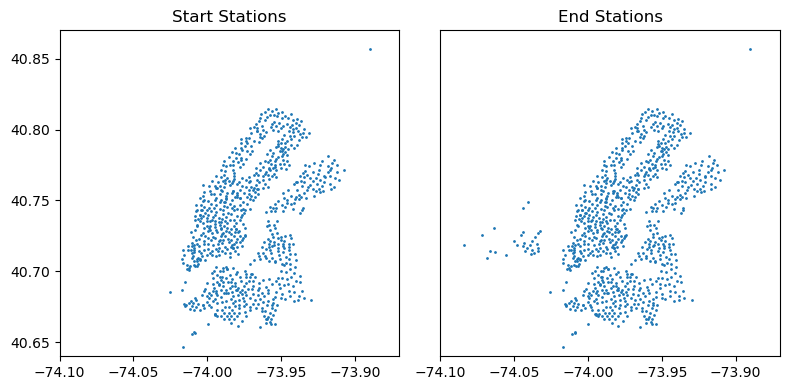

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.87), (40.64, 40.87)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

### Classifying the stations with ID: NaN

We find that a great deal of stations have ID = NaN. So we try and plot them to find their location.

In [20]:
start_ids = np.unique(f.start_station_id)
end_ids = np.unique(f.end_station_id)
print(f"Number of NaN values in start_station_id: {f.start_station_id.isna().sum()}")
print(f"Number of NaN values in end_station_id: {f.end_station_id.isna().sum()}")
start_station_df[start_station_df.index.isna()]

Number of NaN values in start_station_id: 2497
Number of NaN values in end_station_id: 2497


,latitude,longitude
start_station_id,,
NaN,40.857,-73.89


2497 trips have a station ID with NaN-value

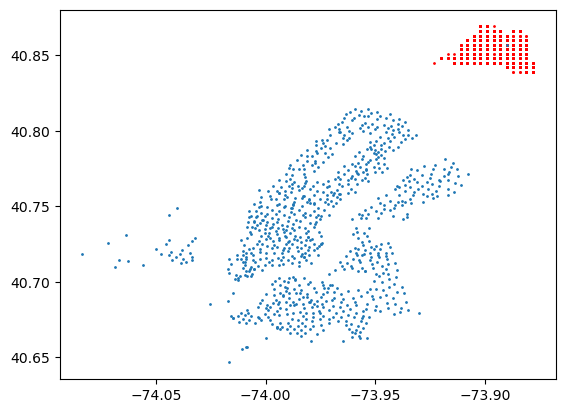

In [21]:
f_nan = f[f.start_station_id.isna()][['start_station_longitude', 'start_station_latitude']]
plt.scatter(f_nan.start_station_longitude, f_nan.start_station_latitude, s=1, c='r', label="NaN-station")
plt.scatter(end_station_df['longitude'], end_station_df['latitude'], s=1)
plt.show()

In [22]:
print("\nCheck: Are the placements different? If all 0, then all placements same")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude) - np.unique(f[f.start_station_id.isna()].end_station_longitude))
print(np.unique(f[f.end_station_id.isna()].start_station_longitude) - np.unique(f[f.end_station_id.isna()].end_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude) - np.unique(f[f.start_station_id.isna()].end_station_latitude))
print(np.unique(f[f.end_station_id.isna()].start_station_latitude) - np.unique(f[f.end_station_id.isna()].end_station_latitude))

print("\nValues for longitude and latitude")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude))

print(f"\nNumber of stations with NaN-value as ID: {len(np.unique(f[f.start_station_id.isna()].start_station_longitude))}")


Check: Are the placements different? If all 0, then all placements same
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Values for longitude and latitude
[-73.923 -73.92  -73.917 -73.914 -73.911 -73.908 -73.905 -73.902 -73.899
 -73.896 -73.893 -73.89  -73.887 -73.884 -73.881 -73.878]
[40.839 40.842 40.845 40.848 40.851 40.854 40.857 40.86  40.863 40.866
 40.869]

Number of stations with NaN-value as ID: 16


Okay, all 16 NaN-ID-stations are located in a single 'cluster' or grouping.
Looking at the placement in a map, the red grouping lies in the Bronx area North of New York. Also as a result of our plotting the single blue dot is the result of dropping duplicates on the ID's. This means that it, in previous plots, represented all the red dots, we now found.

We check whether or not we have data on any trips leaving this grouping. 

In [23]:
f[(f.start_station_id.isna()) & (f.end_station_id.notna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [24]:
f[(f.start_station_id.notna()) & (f.end_station_id.isna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


Okay, no trips from a NaN-ID-station leaves the grouping in the Bronx area. Hence, they have no implication on clusters in the central New York area. Since that is the case they wont be important for rebalancing the bike locations, so we classicy them as outliers

In [25]:
f = f.dropna()

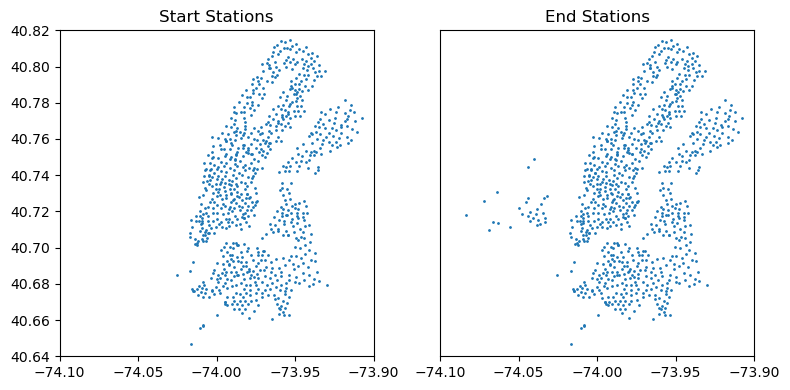

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.9), (40.64, 40.82)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

# Cluster stations spatially with K-means

DB-scan tends to either produce way over 20 or too few clusters

In the following cell we make an K-means spartial clustering with K = 20 for the startstation ID's and endstation ID's. We compute the siloutte scores of the clustering. The clustering and the silouttes are plottet.  

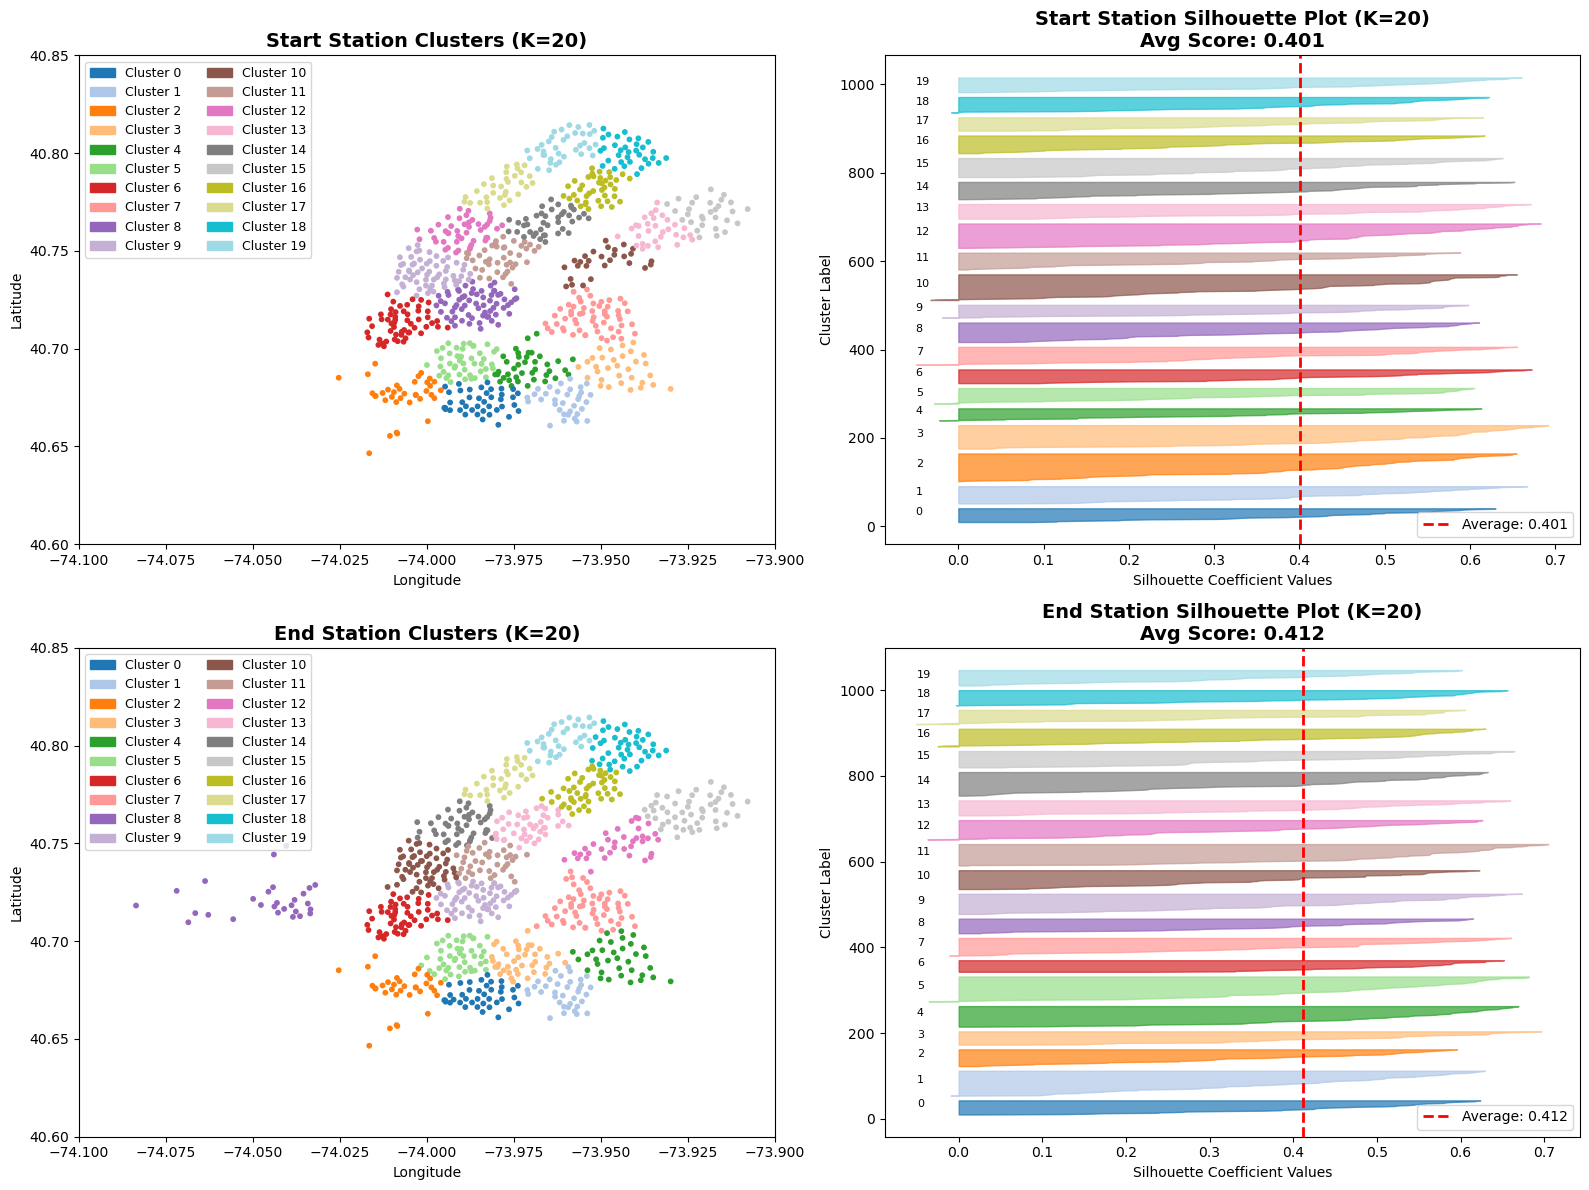

Start Station Average Silhouette Score: 0.401
End Station Average Silhouette Score: 0.412


In [27]:
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import random

K=20

# Fit K-means for start stations
k_start=KMeans(K, random_state=42, n_init=30)
k_end=KMeans(K, random_state=42, n_init=30)

k_start.fit(start_station_df)
k_end.fit(end_station_df)
centroids_start = k_start.cluster_centers_
centroids_end = k_end.cluster_centers_

# Fixing labelling start
order = np.argsort(centroids_start[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_start = np.array([mapping[label] for label in k_start.labels_])

# Fixing labelling end
order = np.argsort(centroids_end[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_end = np.array([mapping[label] for label in k_end.labels_])

dt_clusters_start=start_station_df.copy()
dt_clusters_start['cluster']= fix_labels_start

dt_clusters_end=end_station_df.copy()
dt_clusters_end['cluster']=fix_labels_end
"""
# Generate colors
num_colors=K
colors=list(mcolors.CSS4_COLORS.keys())
cluster_colors_start = random.choices(colors,k=K)
cluster_colors_end = random.choices(colors,k=K)
"""
# Fixed color palette for reproducibility
# -----------------------------
palette = plt.cm.tab20.colors  # up to 20 clusters

unique_start_labels = sorted(set(dt_clusters_start["cluster"]))
unique_start_labels = [l for l in unique_start_labels if l != -1]
cluster_colors_start = {label: palette[i % len(palette)] for i, label in enumerate(unique_start_labels)}

unique_end_labels = sorted(set(dt_clusters_end["cluster"]))
unique_end_labels = [l for l in unique_end_labels if l != -1]
cluster_colors_end = {label: palette[i % len(palette)] for i, label in enumerate(unique_end_labels)}


# Prepare data for start stations
x_points_start=dt_clusters_start["longitude"]
y_points_start=dt_clusters_start["latitude"]
labels_start = dt_clusters_start["cluster"]
x_start=[]
y_start=[]
c_start=[]
for label, x, y in zip(labels_start, x_points_start, y_points_start):
    if label == -1:
        continue
    x_start.append(x)
    y_start.append(y)
    c_start.append(cluster_colors_start[label])

# Prepare data for end stations
x_points_end=dt_clusters_end["longitude"]
y_points_end=dt_clusters_end["latitude"]
labels_end = dt_clusters_end["cluster"]
x_end=[]
y_end=[]
c_end=[]
for label, x, y in zip(labels_end, x_points_end, y_points_end):
    if label==-1:
        continue
    x_end.append(x)
    y_end.append(y)
    c_end.append(cluster_colors_end[label])

# Calculate silhouette scores
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

silhouette_avg_start = silhouette_score(start_station_df, k_start.labels_)
sample_silhouette_values_start = silhouette_samples(start_station_df, k_start.labels_)

silhouette_avg_end = silhouette_score(end_station_df, k_end.labels_)
sample_silhouette_values_end = silhouette_samples(end_station_df, k_end.labels_)

# Create combined plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Start Station Clusters
ax1 = axes[0, 0]
ax1.scatter(x_start, y_start, s=10, c=c_start)
ax1.set_xlim(-74.1, -73.9)
ax1.set_ylim(40.6, 40.85)
ax1.set_title(f'Start Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
legend_patches_start = [Patch(color=cluster_colors_start[i], label=f"Cluster {i}") for i in range(K)]
ax1.legend(handles=legend_patches_start, loc='upper left', fontsize=9, ncol=2)

# Plot 2: Start Station Silhouette Plot
ax2 = axes[0, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_start[k_start.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_start[i]
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax2.set_title(f"Start Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_start:.3f}", 
              fontsize=14, fontweight='bold')
ax2.set_xlabel("Silhouette Coefficient Values")
ax2.set_ylabel("Cluster Label")
ax2.axvline(x=silhouette_avg_start, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_start:.3f}")
ax2.legend()

# Plot 3: End Station Clusters
ax3 = axes[1, 0]
ax3.scatter(x_end, y_end, s=10, c=c_end)
ax3.set_xlim(-74.1, -73.9)
ax3.set_ylim(40.6, 40.85)
ax3.set_title(f'End Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
legend_patches_end = [Patch(color=cluster_colors_end[i], label=f"Cluster {i}") for i in range(K)]
ax3.legend(handles=legend_patches_end, loc='upper left', fontsize=9, ncol=2)

# Plot 4: End Station Silhouette Plot
ax4 = axes[1, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_end[k_end.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_end[i]
    ax4.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax4.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax4.set_title(f"End Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_end:.3f}", 
              fontsize=14, fontweight='bold')
ax4.set_xlabel("Silhouette Coefficient Values")
ax4.set_ylabel("Cluster Label")
ax4.axvline(x=silhouette_avg_end, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_end:.3f}")
ax4.legend()

plt.tight_layout()
plt.show()

print(f"Start Station Average Silhouette Score: {silhouette_avg_start:.3f}")
print(f"End Station Average Silhouette Score: {silhouette_avg_end:.3f}")

The following cell plots the clustering with the stations on a map on new york corresponding to there location

In [ ]:
# Visualize clusters on a map using GeoPandas and Contextily
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
import numpy as np
import pyproj
from matplotlib.patches import Patch

# -----------------------------
# Build correct GeoDataFrames
# -----------------------------
gdf_start = gpd.GeoDataFrame(
    dt_clusters_start[["cluster"]],
    geometry=[Point(xy) for xy in zip(
        dt_clusters_start["longitude"],
        dt_clusters_start["latitude"]
    )],
    crs="EPSG:4326"
)

gdf_end = gpd.GeoDataFrame(
    dt_clusters_end[["cluster"]],
    geometry=[Point(xy) for xy in zip(
        dt_clusters_end["longitude"],
        dt_clusters_end["latitude"]  # FIXED: used correct y-coordinate
    )],
    crs="EPSG:4326"
)


# Convert to Web Mercator
gdf_start_3857 = gdf_start.to_crs(3857)
gdf_end_3857 = gdf_end.to_crs(3857)

# -----------------------------
# Fixed color palette for reproducibility
# -----------------------------
palette = plt.cm.tab20.colors  # up to 20 clusters

unique_start_labels = sorted(set(gdf_start["cluster"]))
unique_start_labels = [l for l in unique_start_labels if l != -1]
cluster_colors_start = {label: palette[i % len(palette)] for i, label in enumerate(unique_start_labels)}

unique_end_labels = sorted(set(gdf_end["cluster"]))
unique_end_labels = [l for l in unique_end_labels if l != -1]
cluster_colors_end = {label: palette[i % len(palette)] for i, label in enumerate(unique_end_labels)}

# -----------------------------
# Plot Setup
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
ax1, ax2 = axes

# -----------------------------
# START STATION CLUSTERS
# -----------------------------
unique_start_labels = sorted(set(gdf_start["cluster"]))
unique_start_labels = [l for l in unique_start_labels if l != -1]

for label in unique_start_labels:
    mask = gdf_start_3857["cluster"] == label    # FIXED column name
    gdf_start_3857[mask].plot(
        ax=ax1,
        markersize=7,
        color=cluster_colors_start[label],
        label=f"Cluster {label}",
        alpha=0.9
    )

ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron)
ax1.set_title(f"Start Station Clusters (K={K})", fontsize=14, fontweight="bold")

# Legend
ax1.legend(
    handles=[Patch(color=cluster_colors_start[i], label=f"Cluster {i}") for i in unique_start_labels],
    loc='upper left',
    fontsize=9
)

# -----------------------------
# END STATION CLUSTERS
# -----------------------------
unique_end_labels = sorted(set(gdf_end["cluster"]))
unique_end_labels = [l for l in unique_end_labels if l != -1]

for label in unique_end_labels:
    mask = gdf_end_3857["cluster"] == label     # FIXED column name
    gdf_end_3857[mask].plot(
        ax=ax2,
        markersize=7,
        color=cluster_colors_end[label],
        label=f"Cluster {label}",
        alpha=0.9
    )

ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron)
ax2.set_title(f"End Station Clusters (K={K})", fontsize=14, fontweight="bold")

# Legend
ax2.legend(
    handles=[Patch(color=cluster_colors_end[i], label=f"Cluster {i}") for i in unique_end_labels],
    loc='upper left',
    fontsize=9
)

# -----------------------------
# Fix Longitude/Latitude ticks
# -----------------------------
project = pyproj.Transformer.from_crs(3857, 4326, always_xy=True)

for ax in axes:
    xticks = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 6)
    yticks = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 6)

    xt_lab, yt_lab = project.transform(xticks, yticks)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([f"{x:.4f}" for x in xt_lab])
    ax.set_yticklabels([f"{y:.4f}" for y in yt_lab])

plt.tight_layout()
plt.show()

'\nimport matplotlib.pyplot as plt\nimport geopandas as gpd\nfrom shapely.geometry import Point\nimport contextily as ctx\nimport numpy as np\nimport pyproj\nfrom matplotlib.patches import Patch\n\n# -----------------------------\n# Build correct GeoDataFrames\n# -----------------------------\ngdf_start = gpd.GeoDataFrame(\n    dt_clusters_start[["cluster"]],\n    geometry=[Point(xy) for xy in zip(\n        dt_clusters_start["longitude"],\n        dt_clusters_start["latitude"]\n    )],\n    crs="EPSG:4326"\n)\n\ngdf_end = gpd.GeoDataFrame(\n    dt_clusters_end[["cluster"]],\n    geometry=[Point(xy) for xy in zip(\n        dt_clusters_end["longitude"],\n        dt_clusters_end["latitude"]  # FIXED: used correct y-coordinate\n    )],\n    crs="EPSG:4326"\n)\n\n\n# Convert to Web Mercator\ngdf_start_3857 = gdf_start.to_crs(3857)\ngdf_end_3857 = gdf_end.to_crs(3857)\n\n# -----------------------------\n# Fixed color palette for reproducibility\n# -----------------------------\npalette = plt

# Load a fixed labelling from file

In [29]:
np.savetxt('fix_labels_start.txt', fix_labels_start) # for updating the fixed cluster labelling used


fixed_cluster_labels = np.loadtxt('fix_labels_start.txt')
dt_clusters_all = dt_clusters_start.copy() # We are told to use the start station clusters for all operations
dt_clusters_all['cluster'] = fixed_cluster_labels

# Aggregating trips per hour - zero padding timestamps where no trips where taken 

In [30]:
df_merged_start = f.merge(
    dt_clusters_all['cluster'], 
    left_on='start_station_id', 
    right_index=True, 
    how='left'
)
# df_merged_start = df_merged_start.drop(columns=['Unnamed: 0'])

df_merged_end = f.merge(
    dt_clusters_all['cluster'], 
    left_on='end_station_id', 
    right_index=True, 
    how='left'
)

In [31]:
# Make sure starttime is a datetime
df_merged_start['starttime'] = pd.to_datetime(df_merged_start['starttime'])

# Extract date and hour
df_merged_start['date'] = df_merged_start['starttime'].dt.date
df_merged_start['hour'] = df_merged_start['starttime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_all = df_merged_start.groupby(['date', 'hour']).size().reset_index(name='num_trips')

trips_per_hour_all['datetime'] = pd.to_datetime(trips_per_hour_all['date'].astype(str)) + pd.to_timedelta(trips_per_hour_all['hour'], unit='h')
trips_per_hour_all.set_index('datetime', inplace=True)
all_dates = np.unique(trips_per_hour_all.index.date)
all_hours = pd.Index(range(24), name='hour')

full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names = ['date', 'hour']
)

trips_per_hour_all = (
    trips_per_hour_all
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

trips_per_hour_all['datetime'] = pd.to_datetime(trips_per_hour_all['date'].astype(str)) + pd.to_timedelta(trips_per_hour_all['hour'], unit='h')
trips_per_hour_all.set_index('datetime', inplace=True)
trips_per_hour_all.drop(columns=['date'], inplace=True)
#trips_per_hour_all.drop(columns=['hour'], inplace=True)

trips_per_hour_all

,hour,num_trips
datetime,,
2018-01-01 00:00:00,0,119
2018-01-01 01:00:00,1,168
2018-01-01 02:00:00,2,98
2018-01-01 03:00:00,3,72
2018-01-01 04:00:00,4,34
...,...,...
2018-12-31 19:00:00,19,168
2018-12-31 20:00:00,20,189
2018-12-31 21:00:00,21,91


# Investigating all the data

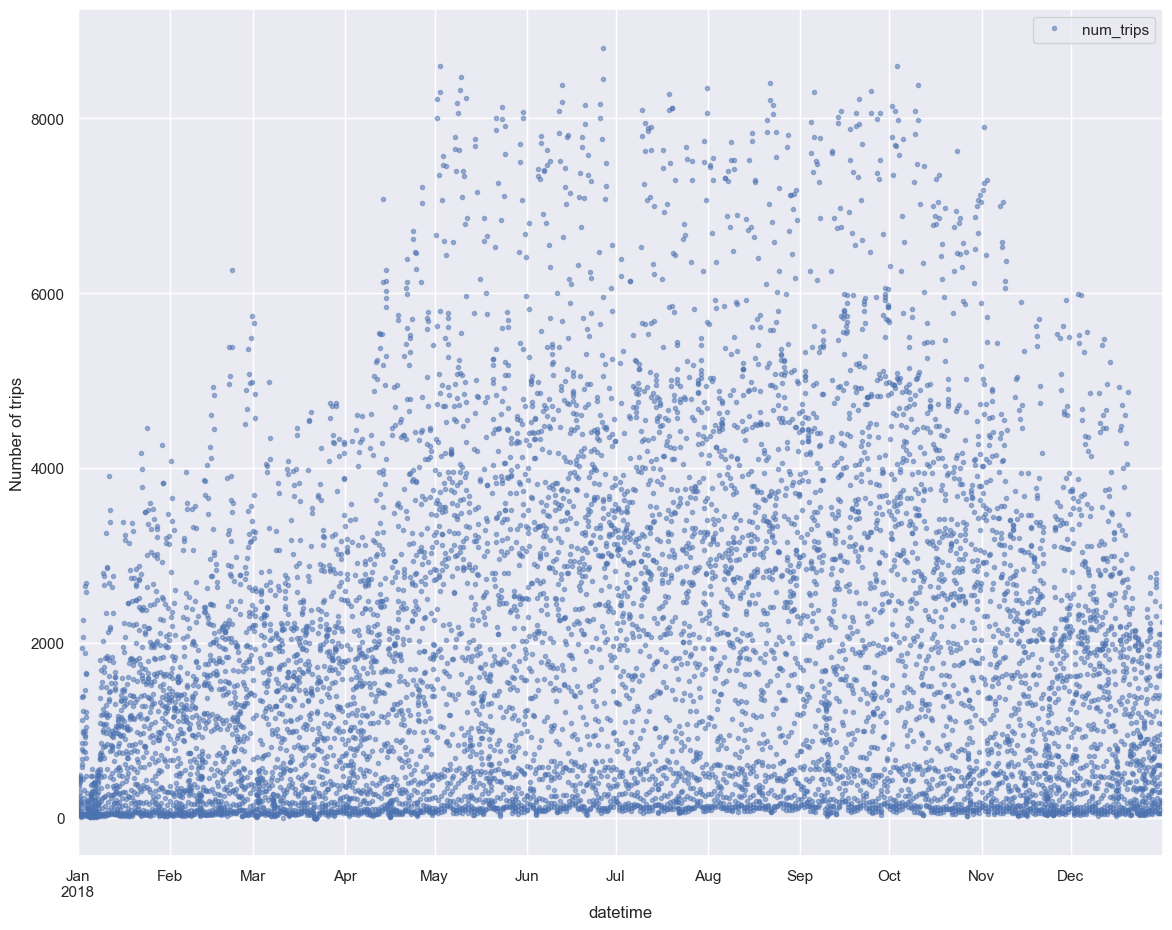

In [32]:
import seaborn as sns
# Plot numbr of trips 
sns.set_theme(rc={'figure.figsize':(14, 5)})
cols_plot = ['num_trips']
axes = trips_per_hour_all[cols_plot].plot(marker='.', alpha=0.5, linestyle='None', figsize=(14, 11), subplots=True)
for ax in axes:
    ax.set_ylabel('Number of trips')

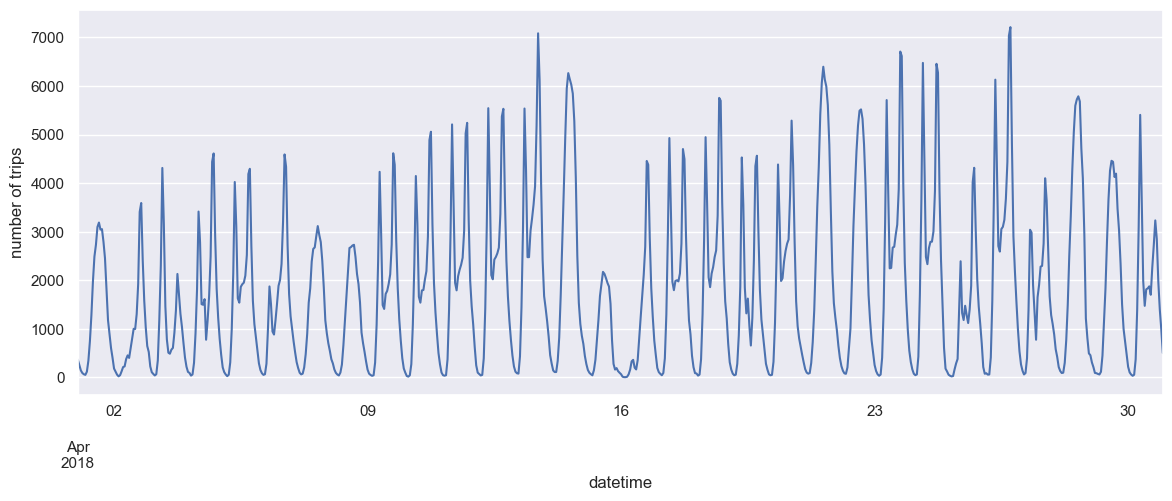

In [33]:
# Plot number of trips for april 

ax = trips_per_hour_all.loc['2018-04', 'num_trips'].plot()
ax.set_ylabel('number of trips')
plt.show()

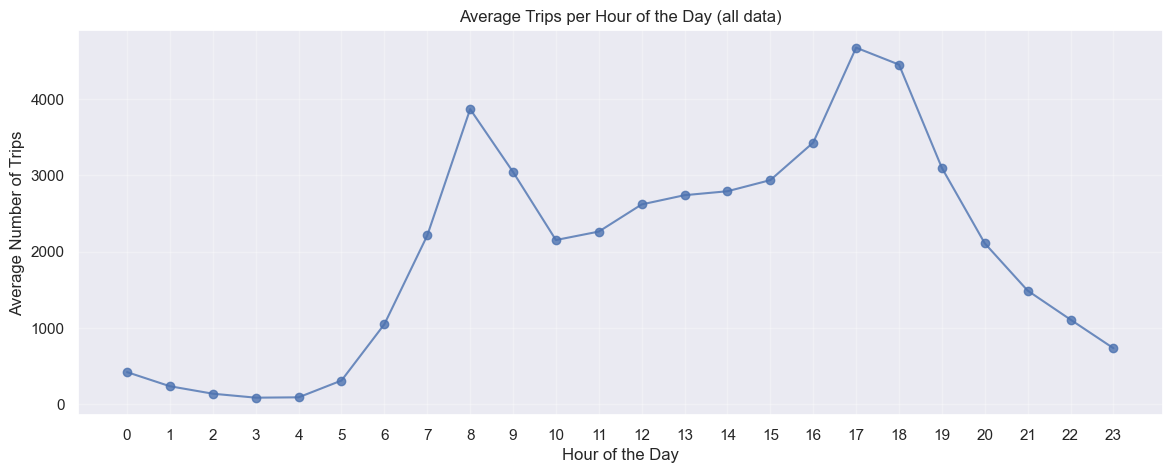

In [34]:
# Average trips per hour (0-23) across all days
avg_trips_by_hour_all = trips_per_hour_all.groupby('hour')['num_trips'].mean()
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(rc={'figure.figsize':(14, 5)})

# Plot average trips by hour
avg_trips_by_hour_all.plot(marker='o', linestyle='-', alpha=0.8)

plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Trips')
plt.title('Average Trips per Hour of the Day (all data)')
plt.xticks(range(0,24))  # ensure all hours are labeled
plt.grid(True, alpha=0.3)
plt.show()

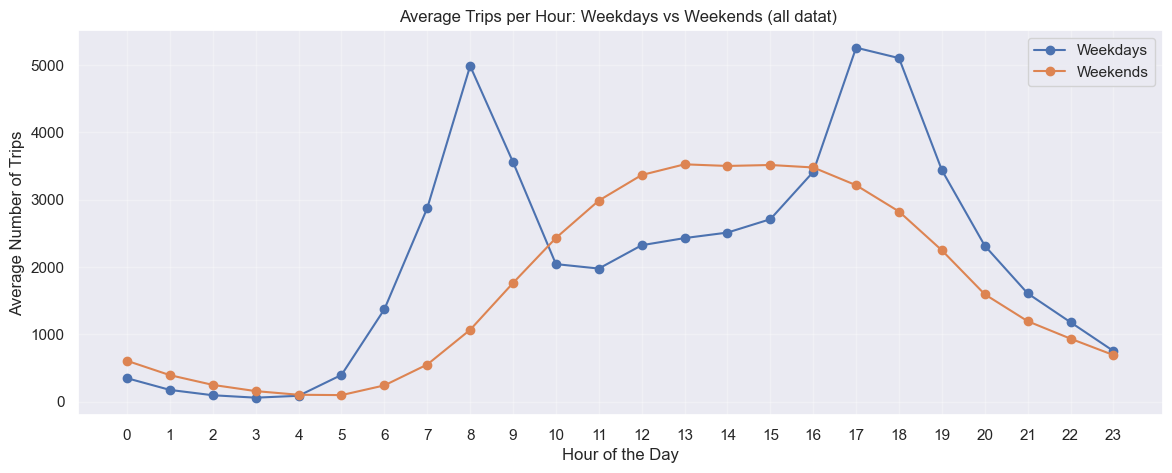

In [35]:

# Extract hour from datetime index if not already present
trips_per_hour_all['hour'] = trips_per_hour_all.index.hour
trips_per_hour_all['is_weekend'] = trips_per_hour_all.index.weekday >= 5

# Average trips per hour for weekdays
avg_weekday = trips_per_hour_all[~trips_per_hour_all['is_weekend']].groupby('hour')['num_trips'].mean()

# Average trips per hour for weekends
avg_weekend = trips_per_hour_all[trips_per_hour_all['is_weekend']].groupby('hour')['num_trips'].mean()

# Plot
sns.set(rc={'figure.figsize':(14,5)})
plt.plot(avg_weekday.index, avg_weekday.values, marker='o', linestyle='-', label='Weekdays')
plt.plot(avg_weekend.index, avg_weekend.values, marker='o', linestyle='-', label='Weekends')

plt.xlabel('Hour of the Day')
plt.ylabel('Average Number of Trips')
plt.title('Average Trips per Hour: Weekdays vs Weekends (all datat) ')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

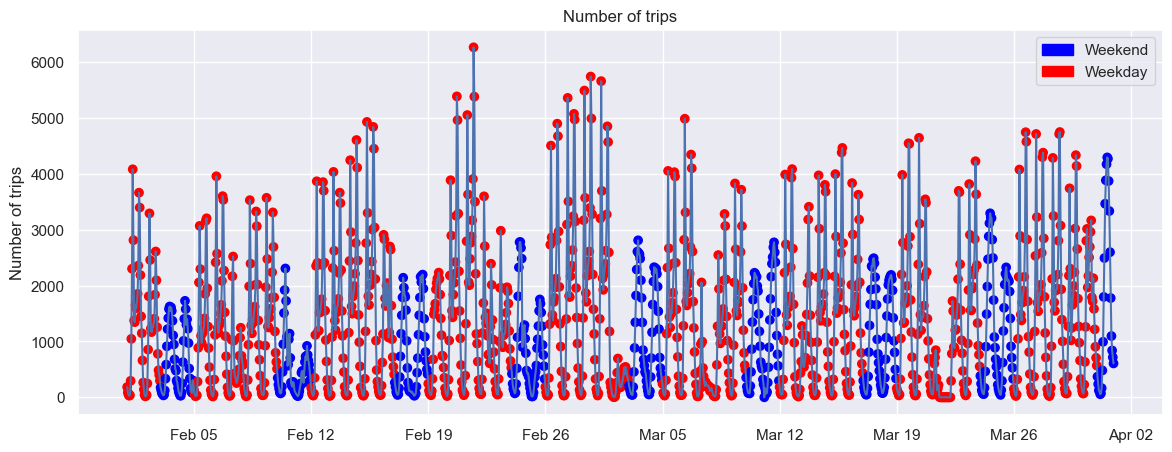

In [36]:
import matplotlib.dates as mdates

#Number of trips Februar to April, weekend and weekdays are indicated
weekends=trips_per_hour_all.loc['2018-02':'2018-03', 'num_trips'].index.weekday>=5
colors=['blue' if x else 'red' for x in weekends]
fig, ax = plt.subplots()
ax.plot(trips_per_hour_all.loc['2018-02':'2018-03', 'num_trips'])
ax.scatter(trips_per_hour_all.loc['2018-02':'2018-03'].index, trips_per_hour_all.loc['2018-02':'2018-03', 'num_trips'], marker='o', linestyle='-', c=colors)
ax.set_ylabel('Number of trips')
ax.set_title('Number of trips')
legend_elements = [Patch(color='blue', label='Weekend'),
                   Patch(color='red', label='Weekday')]
ax.legend(handles=legend_elements, loc='upper right')


# Set x-axis major ticks to weekly interval, on Mondays
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY))
# Format x-tick labels as 3-letter month name and day number
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'));

In [37]:
# Conducting a AD-fuller test
from statsmodels.tsa.stattools import adfuller
result = adfuller(trips_per_hour_all['num_trips'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
   print('\t%s: %.3f' % (key, value))

ADF Statistic: -8.188112
p-value: 0.000000
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567


## Exploring seasonality in all data 

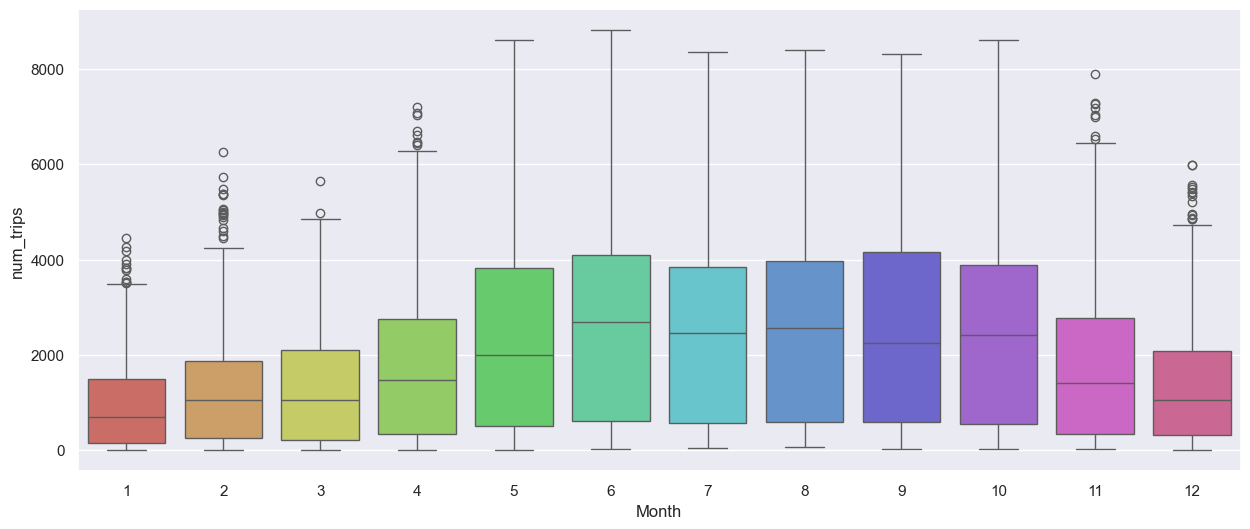

In [38]:
# Box plot trips per hour for months 
fig, axes = plt.subplots(1, 1, figsize=(15, 6), sharex=True)
trips_per_hour_all['Month'] = trips_per_hour_all.index.month
sns.boxplot(data=trips_per_hour_all, x='Month', y='num_trips', ax=axes, hue='Month',palette=sns.color_palette("hls", 12),legend=False)
ax.set_ylabel('Number of trips')
ax.set_title('Boxplot of number of trips in each month')
plt.show()

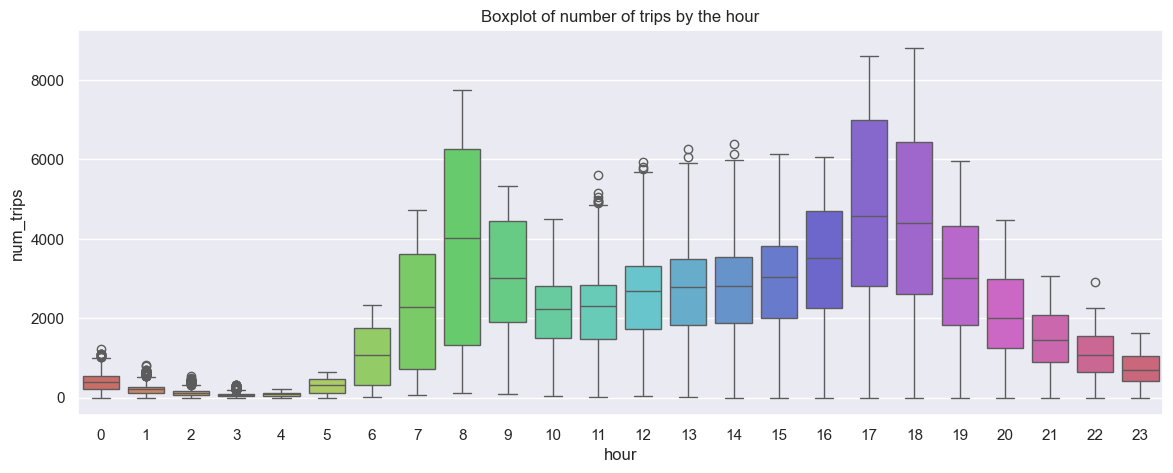

In [39]:
# Box plot trips pr. hour pr hour of average day. 
sns.boxplot(data=trips_per_hour_all, x='hour', y='num_trips',hue='hour',palette=sns.color_palette("hls", 24),legend=False)
plt.title('Boxplot of number of trips by the hour')
plt.show()

##  Rolling average

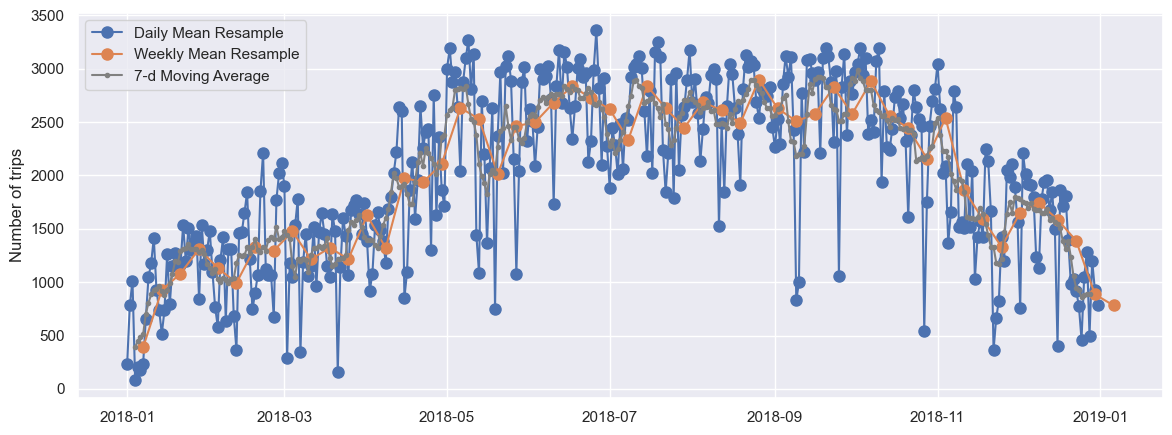

In [40]:
data_columns = ['num_trips']
opsd_daily_mean = trips_per_hour_all[data_columns].resample('D').mean()
opsd_daily_mean[:3]
opsd_weekly_mean = trips_per_hour_all[data_columns].resample('W').mean()
opsd_weekly_mean[:3]

opsd_7d = opsd_daily_mean[data_columns].rolling(7, center=True).mean()
opsd_7d.head(10)

start, end = '2018-01', '2019-01'
# Plot daily and weekly resampled time series together
fig, ax = plt.subplots()
ax.plot(opsd_daily_mean.loc[start:end, 'num_trips'],
marker='o', markersize=8, linestyle='-', label='Daily Mean Resample')
ax.plot(opsd_weekly_mean.loc[start:end, 'num_trips'],
marker='o', markersize=8, linestyle='-', label='Weekly Mean Resample')
ax.plot(opsd_7d.loc[start:end, 'num_trips'],
marker='.', linestyle='-', label='7-d Moving Average', color="grey")
ax.set_ylabel('Number of trips')
ax.legend()

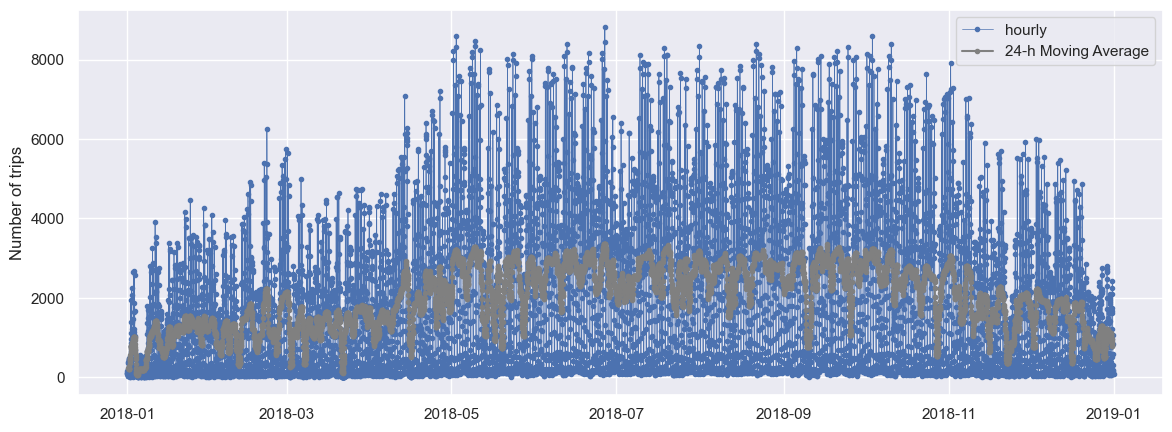

In [41]:

opsd_24h = trips_per_hour_all[data_columns].rolling(24, center=True).mean()
start, end = '2018-01', '2019-01'
# Plot daily and weekly resampled time series together
fig, ax = plt.subplots()
ax.plot(trips_per_hour_all.loc[start:end, 'num_trips'],
marker='.', linestyle='-', linewidth=0.5, label='hourly')
ax.plot(opsd_24h.loc[start:end, 'num_trips'],
marker='.', linestyle='-', label='24-h Moving Average', color="grey")
ax.set_ylabel('Number of trips')
ax.legend()

## Autocorrelation 

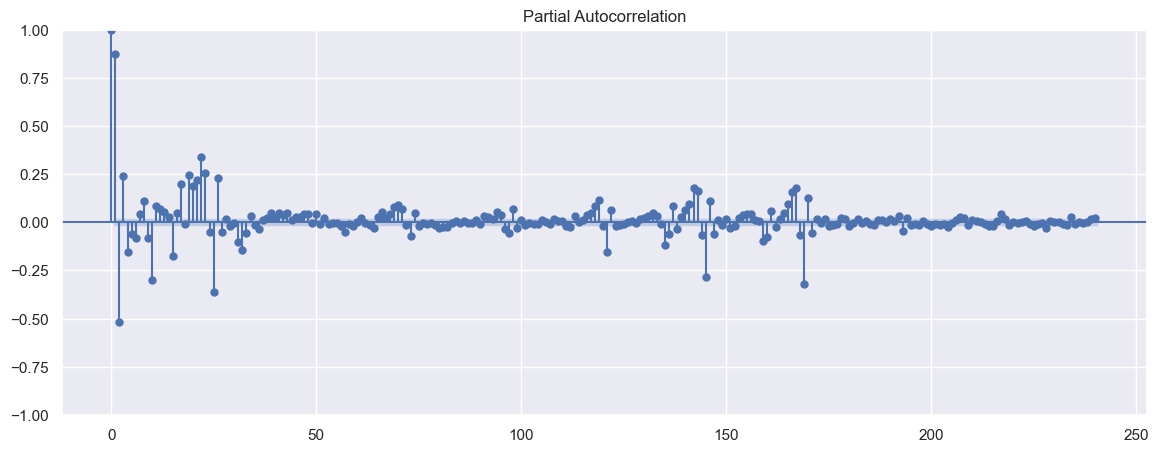

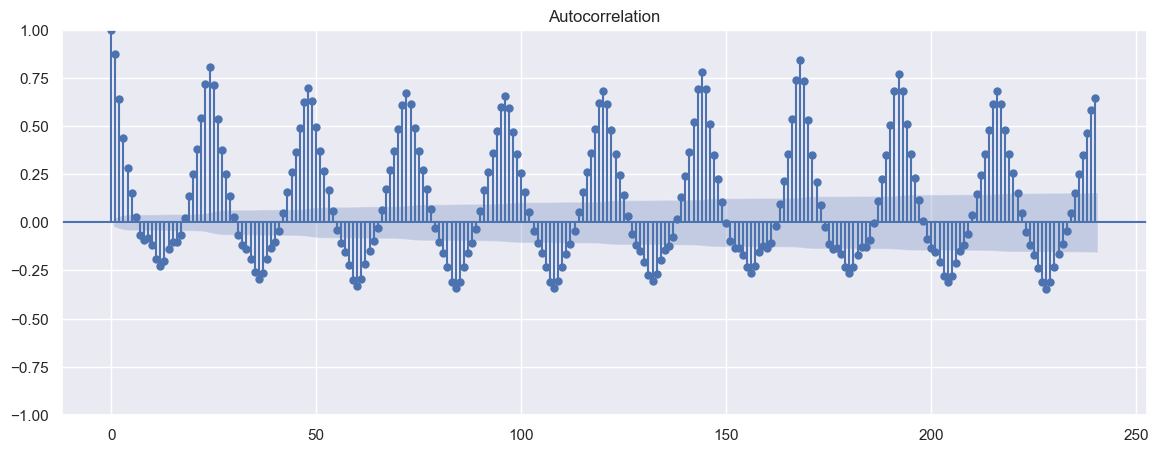

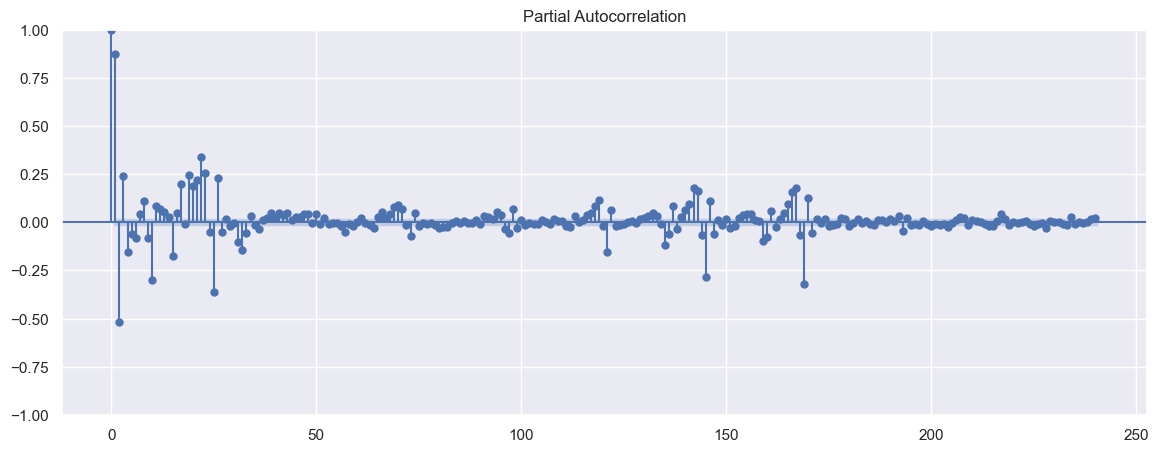

In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(trips_per_hour_all['num_trips'],lags=10*24) # lags valgt udfra 10 dage gnage 24 timer
plot_pacf(trips_per_hour_all['num_trips'],lags=10*24)

# Naive Prediction Model 

## Cluster 4

In [43]:
# Extracting datepoints for cluster 4 
cluster_4_departures = df_merged_start[df_merged_start["cluster"] == 4].copy()
cluster_4_arrivals = df_merged_end[df_merged_end['cluster'] == 4].copy()
cluster_4_departures.size, cluster_4_arrivals.size

(8752536, 7589120)

### Clean up dataframes 

#### Clean up arrivals dataframe 

In [44]:

# Make sure starttime is a datetime
cluster_4_arrivals['stoptime'] = pd.to_datetime(cluster_4_arrivals['stoptime'])

# Extract date and hour
cluster_4_arrivals['date'] = cluster_4_arrivals['stoptime'].dt.date
cluster_4_arrivals['hour'] = cluster_4_arrivals['stoptime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_arrivals= cluster_4_arrivals.groupby(['date', 'hour'])
trips_per_hour_arrivals.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster,date,hour
Trip ID,,,,,,,,,,,,,,,,,,
2051,1313,2018-01-24 09:12:55.376,2018-01-24 09:34:48.533,79.0,40.719116,-74.006667,242.0,40.697787,-73.973736,32585,Subscriber,1983,1,2,False,4.0,2018-01-24,9
2707,1267,2018-01-22 17:29:54.723,2018-01-22 17:51:02.091,82.0,40.711174,-74.000165,3455.0,40.686808,-73.980362,31410,Subscriber,1969,1,0,False,4.0,2018-01-22,17
2867,162,2018-01-01 14:56:10.536,2018-01-01 14:58:53.280,83.0,40.683826,-73.976323,3414.0,40.680945,-73.975673,33431,Subscriber,1975,2,0,False,4.0,2018-01-01,14
2871,566,2018-01-01 18:23:45.044,2018-01-01 18:33:11.374,83.0,40.683826,-73.976323,262.0,40.691782,-73.973730,32309,Subscriber,1977,1,0,False,4.0,2018-01-01,18
2873,454,2018-01-01 21:44:49.900,2018-01-01 21:52:24.423,83.0,40.683826,-73.976323,270.0,40.693083,-73.971789,32335,Subscriber,1980,1,0,False,4.0,2018-01-01,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17548232,249,2018-12-31 22:35:42.645,2018-12-31 22:39:52.255,3410.0,40.686444,-73.987591,467.0,40.683125,-73.978951,18157,Customer,1969,0,0,False,4.0,2018-12-31,22
17548269,317,2018-12-31 23:03:31.570,2018-12-31 23:08:49.156,274.0,40.686919,-73.976682,275.0,40.686501,-73.965633,19468,Subscriber,2002,1,0,False,4.0,2018-12-31,23
17548293,303,2018-12-31 23:18:56.184,2018-12-31 23:23:59.389,390.0,40.692216,-73.984284,270.0,40.693083,-73.971789,14736,Subscriber,1987,1,0,False,4.0,2018-12-31,23


In [45]:
# Chosing relavant features 
grouped_arrivals = (
    cluster_4_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)

grouped_arrivals.head()

,date,hour,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,,,
2018-01-01 00:00:00,2018-01-01,0,4,False,Subscriber,1,414.250000,1982.750000
2018-01-01 01:00:00,2018-01-01,1,5,False,Subscriber,1,1337.000000,1981.200000
2018-01-01 02:00:00,2018-01-01,2,6,False,Subscriber,1,713.666667,1976.666667
2018-01-01 03:00:00,2018-01-01,3,5,False,Subscriber,1,1105.000000,1986.400000
2018-01-01 04:00:00,2018-01-01,4,5,False,Subscriber,1,374.200000,1977.200000


In [46]:
# Zero padding where there where taken no trips 
all_dates = np.unique(grouped_arrivals.index.date)
all_hours = pd.Index(range(24), name='hour')

full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names = ['date', 'hour']
)

grouped_arrivals = (
    grouped_arrivals
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)
grouped_arrivals.head(10)

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,4,False,Subscriber,1,414.250000,1982.750000
2018-01-01 01:00:00,5,False,Subscriber,1,1337.000000,1981.200000
2018-01-01 02:00:00,6,False,Subscriber,1,713.666667,1976.666667
2018-01-01 03:00:00,5,False,Subscriber,1,1105.000000,1986.400000
2018-01-01 04:00:00,5,False,Subscriber,1,374.200000,1977.200000
2018-01-01 05:00:00,0,0,0,0,0.000000,0.000000
2018-01-01 06:00:00,2,False,Subscriber,1,690.500000,1970.500000
2018-01-01 07:00:00,1,False,Subscriber,1,399.000000,1984.000000
2018-01-01 08:00:00,2,False,Subscriber,1,751.500000,1982.000000


#### Clean up departures Data frame

In [47]:
# Make sure starttime is a datetime
cluster_4_departures['starttime'] = pd.to_datetime(cluster_4_departures['starttime'])

# Extract date and hour
cluster_4_departures['date'] = cluster_4_departures['starttime'].dt.date
cluster_4_departures['hour'] = cluster_4_departures['starttime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_decluster_4_departures= cluster_4_departures.groupby(['date', 'hour'])
trips_per_hour_decluster_4_departures.head()

# Chosing relavant features 
grouped_departures = (
    cluster_4_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

# Zero padding where there where taken no trips 
grouped_departures = (
    grouped_departures
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)

grouped_departures

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,2,False,Subscriber,1,216.0,1976.000000
2018-01-01 01:00:00,3,False,Subscriber,1,955.0,1981.333333
2018-01-01 02:00:00,4,False,Subscriber,1,448.5,1981.500000
2018-01-01 03:00:00,1,False,Subscriber,1,303.0,1989.000000
2018-01-01 04:00:00,1,False,Subscriber,1,227.0,1969.000000
...,...,...,...,...,...,...
2019-01-04 19:00:00,0,0,0,0,0.0,0.000000
2019-01-04 20:00:00,0,0,0,0,0.0,0.000000
2019-01-04 21:00:00,0,0,0,0,0.0,0.000000


### Naive model prediction of number of trips for arrivals and departures 

In [193]:
def weekday_hour_average(series):
    """
    Predicts hourly trip count based on the historical average for
    each (weekday, hour) combination.
    
    Input:
        series: Pandas Series with DatetimeIndex (hourly data)
    
    Output:
        Pandas Series of predictions aligned with the input index.
    """
    df = series.to_frame("trip_count").copy()

    # Extract weekday (0=Monday,...6=Sunday) and hour of day
    df["weekday"] = df.index.weekday
    df["hour"] = df.index.hour

    # Compute the historical average for each weekday + hour combination
    avg_table = (
        df.groupby(["weekday", "hour"])["trip_count"]
          .mean()
          .round()
          .rename("avg_pred")
    )

    return avg_table

def predict_weekday_hour(series, avg_table):
    """
    Predicts for any datetime-indexed series using a fitted avg_table.
    """
    df = series.to_frame("x").copy()
    df["weekday"] = df.index.weekday
    df["hour"] = df.index.hour

    # map (weekday, hour) → prediction
    preds = [
        avg_table.loc[(w, h)]
        for w, h in zip(df["weekday"], df["hour"])
    ]
    
    return pd.Series(preds, index=df.index)

def simple_set_font_size(ax, labelsize=14, titlesize=16, legendsize = None) -> None:
    if legendsize is None:
        legendsize = labelsize
    ax.tick_params(axis="both", labelsize=labelsize)
    ax.set_xlabel(ax.get_xlabel(), fontsize=labelsize)
    ax.set_ylabel(ax.get_ylabel(), fontsize=labelsize)
    ax.set_title(ax.get_title(), fontsize=titlesize)
    
    if ax.legend_ is not None:
        ax.legend_.set_fontsize(legendsize)
    else:
        plt.rcParams['legend.fontsize'] = legendsize

def plotprediction(series, pred_series: list[pd.Series] | pd.Series, labels=["original", "predicted"], 
                   x_axis=None, plot_intervals=False, scale=1.96, alpha = 0.5,
                   plot_anomalies=False, title="prediction"):

    plt.figure(figsize=(12,5))
    plt.title(title)
    if x_axis is None:
            x_axis=series.index
    
    if isinstance(pred_series, list):
        plt.plot(x_axis, series, label=labels[0])
        for i, ps in enumerate(pred_series):
            plt.plot(x_axis, ps, label=labels[1] + f' {i}' if len(labels) < len(pred_series)+1 else labels[i+1], alpha = alpha)
    else:
        plt.plot(x_axis, pred_series, "r", label=labels[1], alpha = alpha)
        plt.plot(x_axis, series, 'b', label=labels[0], alpha = alpha)
    

    # Plot confidence intervals for smoothed values

    simple_set_font_size(plt.gca(), labelsize=14, titlesize=16)
    plt.xticks(rotation=30, ha='right')
    plt.legend(loc="upper left")
    plt.grid(True)
    plt.show()

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def print_stats(y_test, y_preds, title="You forgot the title!"):
    print(title+": ")
    print("\tr^2=%f"%r2_score(y_test,y_preds))
    print("\tMSE=%f"%mean_squared_error(y_test,y_preds))
    print("\tMAE=%f"%mean_absolute_error(y_test,y_preds))
    print("\tMAPE=%f"%mean_absolute_percentage_error(y_test,y_preds))

#### Arrivals - trips pr hour prediction 

In [49]:
# Splitting data in the train and test set 
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask = grouped_departures.index < test_start
test_mask  =  (test_stop >grouped_departures.index) & (grouped_departures.index  >= test_start)

# Make sure the index is a DatetimeIndex
grouped_arrivals.index = pd.to_datetime(grouped_arrivals.index)


train_arrivals = grouped_arrivals[train_mask].iloc[:, 0]
test_arrivals  = grouped_arrivals[test_mask].iloc[:, 0]

# Computing the average week on the train set

model_table_arrivals= weekday_hour_average(train_arrivals)
model_table_arrivals[:25]

weekday  hour
0        0        10.0
         1         6.0
         2         3.0
         3         2.0
         4         3.0
         5         9.0
         6        25.0
         7        51.0
         8        94.0
         9        84.0
         10       44.0
         11       42.0
         12       50.0
         13       56.0
         14       56.0
         15       60.0
         16       76.0
         17      115.0
         18      170.0
         19      141.0
         20       96.0
         21       61.0
         22       44.0
         23       27.0
1        0        13.0
Name: avg_pred, dtype: float64

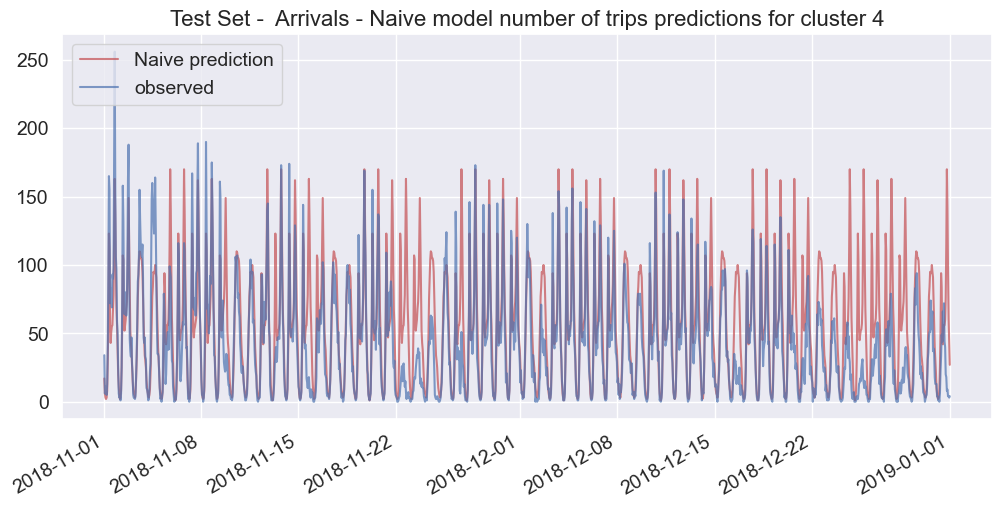

In [50]:
#Prediction number of arrivals 
pred_test_arrivals = predict_weekday_hour(test_arrivals, model_table_arrivals)

#Plotting the number of predicted arrivals vs the observed arrivals  
plotprediction(
    test_arrivals,
    pred_test_arrivals,
    labels=["observed", "Naive prediction"],
    title="Test Set -  Arrivals - Naive model number of trips predictions for cluster 4"
)

In [51]:
# Evaluation of prediction model 
print_stats(test_arrivals, pred_test_arrivals, "Naive method arrivals")

Naive method arrivals: 
	r^2=0.407505
	MSE=920.019809
	MAE=18.970628
	MAPE=inf


#### Depertures -  trips pr hour prediction 

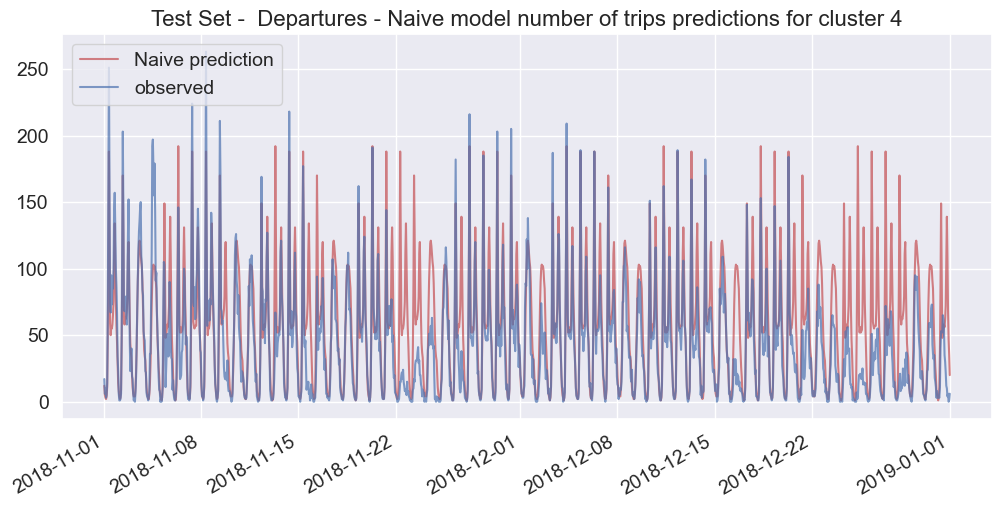

In [52]:
# Make sure the index is a DatetimeIndex
grouped_departures.index = pd.to_datetime(grouped_departures.index)

#Splitting data in to test and train set 
train_departures = grouped_departures[train_mask].iloc[:, 0]
test_departures  = grouped_departures[test_mask].iloc[:, 0]

# Computing the average week based on the train set 
model_table_departures= weekday_hour_average(train_departures)

# Predicting the number of departures 
pred_test_departures = predict_weekday_hour(test_departures, model_table_departures)


#Plotting the number of predicted departures vs the observed arrivals  
plotprediction(
    test_departures,
    pred_test_departures,
    labels=["observed", "Naive prediction"],
    title="Test Set -  Departures - Naive model number of trips predictions for cluster 4",
)


In [53]:
# Evaluation on naive model prediction for departures 
print_stats(test_departures, pred_test_departures, "Naive method departures")

Naive method departures: 
	r^2=0.469399
	MSE=934.183060
	MAE=19.075137
	MAPE=inf


### Prediction for bike allocation

In [54]:
# Computing the difference (diff):  predicted arrivals - departures 
naive_bike_alloc_pred = (pred_test_arrivals - pred_test_departures).to_frame(name="diff")

# Computing the accumulated sum of (diff)
naive_bike_alloc_pred["daily_cumsum"] = naive_bike_alloc_pred.groupby(naive_bike_alloc_pred.index.date)["diff"].cumsum()

# For each day find the smallest accumlated sum 
min_daily_cumsum_pred = naive_bike_alloc_pred.groupby(naive_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

# Assesing how many bike to allocate
min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: abs(x) if x < 0 else 0)
)
min_daily_cumsum_pred

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-159.0,159.0
2018-11-02,-151.0,151.0
2018-11-03,-93.0,93.0
2018-11-04,-72.0,72.0
2018-11-05,-137.0,137.0
...,...,...
2018-12-27,-159.0,159.0
2018-12-28,-151.0,151.0
2018-12-29,-93.0,93.0
2018-12-30,-72.0,72.0


In [55]:
# Computing how many bikes to allocate given the observed arrivals and depatures based in the same policy 

# Computing the difference (diff):  predicted arrivals - departures 
naive_bike_alloc_test = (test_arrivals - test_departures).to_frame(name="diff")

# Computing the accumulated sum of (diff)
naive_bike_alloc_test["daily_cumsum"] = naive_bike_alloc_test.groupby(naive_bike_alloc_test.index.date)["diff"].cumsum()

# For each day find the smallest accumlated sum 
min_daily_cumsum_test = naive_bike_alloc_test.groupby(naive_bike_alloc_test.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

# Assesing how many bike to allocate
min_daily_cumsum_test["bikes_to_allocate"] = (
    min_daily_cumsum_test["min_daily_cumsum"]
    .apply(lambda x: abs(x) if x < 0 else 0)
)

# Safe the test set for bike allocation such that it can be used for the other models. 
min_daily_cumsum_test.to_json("min_daily_cumsum_test_4.json")

min_daily_cumsum_test

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-187,187
2018-11-02,-122,122
2018-11-03,-85,85
2018-11-04,-146,146
2018-11-05,-94,94
...,...,...
2018-12-27,-80,80
2018-12-28,-26,26
2018-12-29,-81,81
2018-12-30,-50,50


In [56]:
# Evaluation the performance of the bike allocation prediction using the naive model
print_stats(min_daily_cumsum_test["bikes_to_allocate"], min_daily_cumsum_pred["bikes_to_allocate"], title="Evaluation of allocation - Naive model")

Evaluation of allocation - Naive model: 
	r^2=-0.289133
	MSE=3198.721311
	MAE=42.262295
	MAPE=133.093406


## Cluster 12

In [57]:
# Extracting datepoints for cluster 4 
cluster_12_departures = df_merged_start[df_merged_start["cluster"] == 12].copy()
cluster_12_arrivals = df_merged_end[df_merged_end['cluster'] == 12].copy()
cluster_12_departures.size, cluster_12_arrivals.size

(36458028, 32485504)

### Clean up dataframes 

#### Clean up arrivals dataframe 

In [58]:

# Make sure starttime is a datetime
cluster_12_arrivals['stoptime'] = pd.to_datetime(cluster_12_arrivals['stoptime'])

# Extract date and hour
cluster_12_arrivals['date'] = cluster_12_arrivals['stoptime'].dt.date
cluster_12_arrivals['hour'] = cluster_12_arrivals['stoptime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_arrivals= cluster_12_arrivals.groupby(['date', 'hour'])
trips_per_hour_arrivals.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster,date,hour
Trip ID,,,,,,,,,,,,,,,,,,
1,723,2018-01-01 15:33:30.182,2018-01-01 15:45:33.341,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1,0,False,12.0,2018-01-01,15
2,496,2018-01-01 15:39:18.337,2018-01-01 15:47:35.172,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1,0,False,12.0,2018-01-01,15
3,306,2018-01-01 15:40:13.372,2018-01-01 15:45:20.191,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1,0,False,12.0,2018-01-01,15
7,434,2018-01-02 08:06:14.331,2018-01-02 08:13:28.767,72.0,40.767272,-73.993929,173.0,40.760683,-73.984527,30525,Subscriber,1983,1,1,False,12.0,2018-01-02,8
8,366,2018-01-02 08:10:15.255,2018-01-02 08:16:21.896,72.0,40.767272,-73.993929,479.0,40.760193,-73.991255,27439,Subscriber,1974,1,1,False,12.0,2018-01-02,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17548187,345,2018-12-31 22:09:46.249,2018-12-31 22:15:31.984,476.0,40.743943,-73.979661,379.0,40.749156,-73.991600,35148,Subscriber,1983,1,0,False,12.0,2018-12-31,22
17548190,144,2018-12-31 22:12:01.431,2018-12-31 22:14:25.866,423.0,40.765849,-73.986905,480.0,40.766697,-73.990617,34971,Subscriber,1981,2,0,False,12.0,2018-12-31,22
17548247,1744,2018-12-31 22:44:35.158,2018-12-31 23:13:39.634,3171.0,40.785247,-73.976673,479.0,40.760193,-73.991255,34701,Customer,1991,1,0,False,12.0,2018-12-31,23


In [59]:
# Chosing relavant features 
grouped_arrivals = (
    cluster_12_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)

grouped_arrivals.head()

,date,hour,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,,,
2018-01-01 00:00:00,2018-01-01,0,4,False,Subscriber,1,786.250000,1986.250000
2018-01-01 01:00:00,2018-01-01,1,19,False,Subscriber,1,698.421053,1979.631579
2018-01-01 02:00:00,2018-01-01,2,10,False,Subscriber,1,654.800000,1974.600000
2018-01-01 03:00:00,2018-01-01,3,8,False,Subscriber,1,456.875000,1976.625000
2018-01-01 04:00:00,2018-01-01,4,3,False,Subscriber,1,427.666667,1985.333333


In [60]:
# Zero padding where there where taken no trips 
all_dates = np.unique(grouped_arrivals.index.date)
all_hours = pd.Index(range(24), name='hour')

full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names = ['date', 'hour']
)

grouped_arrivals = (
    grouped_arrivals
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)
grouped_arrivals.head(10)

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,4,False,Subscriber,1,786.250000,1986.250000
2018-01-01 01:00:00,19,False,Subscriber,1,698.421053,1979.631579
2018-01-01 02:00:00,10,False,Subscriber,1,654.800000,1974.600000
2018-01-01 03:00:00,8,False,Subscriber,1,456.875000,1976.625000
2018-01-01 04:00:00,3,False,Subscriber,1,427.666667,1985.333333
2018-01-01 05:00:00,2,False,Subscriber,2,229.500000,1959.000000
2018-01-01 06:00:00,5,False,Subscriber,1,402.000000,1973.000000
2018-01-01 07:00:00,8,False,Subscriber,1,886.250000,1978.375000
2018-01-01 08:00:00,8,False,Subscriber,1,622.000000,1977.625000


#### Clean up departures Data frame

In [61]:
# Make sure starttime is a datetime
cluster_12_departures['starttime'] = pd.to_datetime(cluster_12_departures['starttime'])

# Extract date and hour
cluster_12_departures['date'] = cluster_12_departures['starttime'].dt.date
cluster_12_departures['hour'] = cluster_12_departures['starttime'].dt.hour

# Group by date and hour, count trips
trips_per_hour_decluster_12_departures= cluster_12_departures.groupby(['date', 'hour'])
trips_per_hour_decluster_12_departures.head()

# Chosing relavant features 
grouped_departures = (
    cluster_12_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

# Zero padding where there where taken no trips 
grouped_departures = (
    grouped_departures
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)

grouped_departures

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,14,False,Subscriber,1,914.642857,1978.071429
2018-01-01 01:00:00,15,False,Subscriber,1,731.600000,1980.266667
2018-01-01 02:00:00,7,False,Subscriber,1,473.142857,1973.857143
2018-01-01 03:00:00,8,False,Subscriber,1,673.125000,1976.000000
2018-01-01 04:00:00,6,False,Subscriber,1,602.666667,1980.166667
...,...,...,...,...,...,...
2019-01-01 19:00:00,0,0,0,0,0.000000,0.000000
2019-01-01 20:00:00,0,0,0,0,0.000000,0.000000
2019-01-01 21:00:00,0,0,0,0,0.000000,0.000000


#### Arrivals - trips pr hour prediction 

In [62]:
# Splitting data in the train and test set 
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask = grouped_departures.index < test_start
test_mask  =  (test_stop >grouped_departures.index) & (grouped_departures.index  >= test_start)

# Make sure the index is a DatetimeIndex
grouped_arrivals.index = pd.to_datetime(grouped_arrivals.index)


train_arrivals = grouped_arrivals[train_mask].iloc[:, 0]
test_arrivals  = grouped_arrivals[test_mask].iloc[:, 0]

# Computing the average week on the train set

model_table_arrivals= weekday_hour_average(train_arrivals)
model_table_arrivals[:25]

weekday  hour
0        0        41.0
         1        23.0
         2        16.0
         3         8.0
         4         9.0
         5        39.0
         6       149.0
         7       302.0
         8       535.0
         9       453.0
         10      217.0
         11      188.0
         12      231.0
         13      265.0
         14      302.0
         15      342.0
         16      472.0
         17      732.0
         18      658.0
         19      408.0
         20      243.0
         21      170.0
         22      122.0
         23       76.0
1        0        40.0
Name: avg_pred, dtype: float64

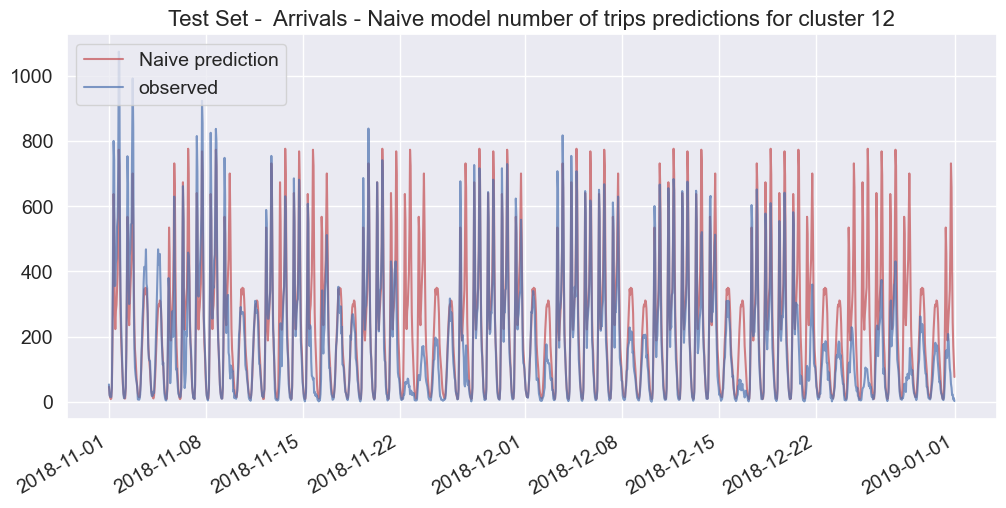

In [63]:
#Prediction number of arrivals 
pred_test_arrivals = predict_weekday_hour(test_arrivals, model_table_arrivals)

#Plotting the number of predicted arrivals vs the observed arrivals  
plotprediction(
    test_arrivals,
    pred_test_arrivals,
    labels=["observed", "Naive prediction"],
    title="Test Set -  Arrivals - Naive model number of trips predictions for cluster 12"
)

In [64]:
# Evaluation of prediction model 
print_stats(test_arrivals, pred_test_arrivals, "Naive method arrivals")

Naive method arrivals: 
	r^2=0.490438
	MSE=17949.232923
	MAE=77.637295
	MAPE=inf


#### Depertures -  trips pr hour prediction 

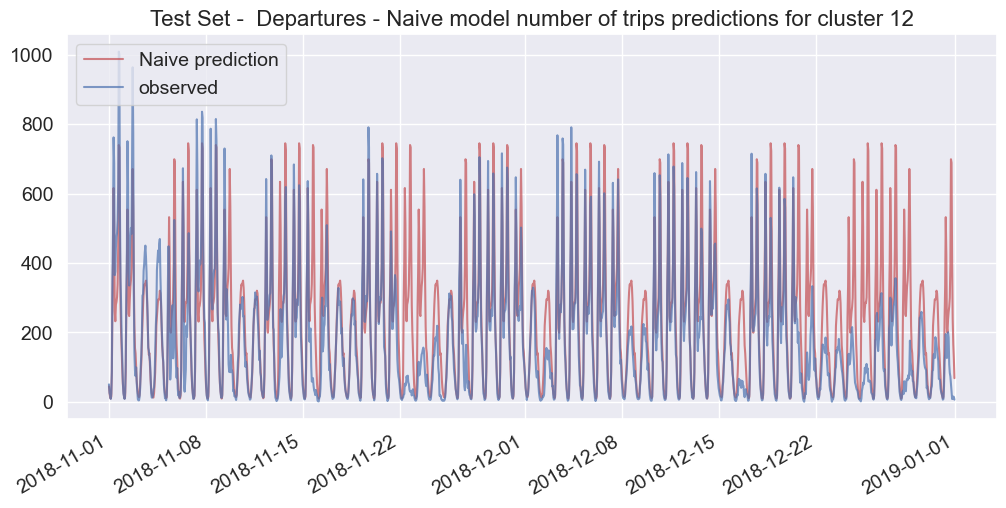

In [65]:
# Make sure the index is a DatetimeIndex
grouped_departures.index = pd.to_datetime(grouped_departures.index)

#Splitting data in to test and train set 
train_departures = grouped_departures[train_mask].iloc[:, 0]
test_departures  = grouped_departures[test_mask].iloc[:, 0]

# Computing the average week based on the train set 
model_table_departures= weekday_hour_average(train_departures)

# Predicting the number of departures 
pred_test_departures = predict_weekday_hour(test_departures, model_table_departures)


#Plotting the number of predicted departures vs the observed arrivals  
plotprediction(
    test_departures,
    pred_test_departures,
    labels=["observed", "Naive prediction"],
    title="Test Set -  Departures - Naive model number of trips predictions for cluster 12",
)


In [66]:
# Evaluation on naive model prediction for departures 
print_stats(test_departures, pred_test_departures, "Naive method departures")

Naive method departures: 
	r^2=0.452603
	MSE=17698.003415
	MAE=78.713798
	MAPE=inf


### Prediction for bike allocation

In [67]:
# Computing the difference (diff):  predicted arrivals - departures 
naive_bike_alloc_pred = (pred_test_arrivals - pred_test_departures).to_frame(name="diff")

# Computing the accumulated sum of (diff)
naive_bike_alloc_pred["daily_cumsum"] = naive_bike_alloc_pred.groupby(naive_bike_alloc_pred.index.date)["diff"].cumsum()

# For each day find the smallest accumlated sum 
min_daily_cumsum_pred = naive_bike_alloc_pred.groupby(naive_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

# Assesing how many bike to allocate
min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: abs(x) if x < 0 else 0)
)
min_daily_cumsum_pred

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-222.0,222.0
2018-11-02,-214.0,214.0
2018-11-03,-117.0,117.0
2018-11-04,-122.0,122.0
2018-11-05,-164.0,164.0
...,...,...
2018-12-27,-222.0,222.0
2018-12-28,-214.0,214.0
2018-12-29,-117.0,117.0
2018-12-30,-122.0,122.0


In [68]:
# Computing how many bikes to allocate given the observed arrivals and depatures based in the same policy 

# Computing the difference (diff):  predicted arrivals - departures 
naive_bike_alloc_test = (test_arrivals - test_departures).to_frame(name="diff")

# Computing the accumulated sum of (diff)
naive_bike_alloc_test["daily_cumsum"] = naive_bike_alloc_test.groupby(naive_bike_alloc_test.index.date)["diff"].cumsum()

# For each day find the smallest accumlated sum 
min_daily_cumsum_test = naive_bike_alloc_test.groupby(naive_bike_alloc_test.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

# Assesing how many bike to allocate
min_daily_cumsum_test["bikes_to_allocate"] = (
    min_daily_cumsum_test["min_daily_cumsum"]
    .apply(lambda x: abs(x) if x < 0 else 0)
)

# Save the test set for bike allocation such that it can be used for the other models. 
min_daily_cumsum_test.to_json("min_daily_cumsum_test_12.json")

min_daily_cumsum_test

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-212,212
2018-11-02,-235,235
2018-11-03,-186,186
2018-11-04,-198,198
2018-11-05,-298,298
...,...,...
2018-12-27,-248,248
2018-12-28,-40,40
2018-12-29,-198,198
2018-12-30,-72,72


In [69]:
# Evaluation the performance of the bike allocation prediction using the naive model
print_stats(min_daily_cumsum_test["bikes_to_allocate"], min_daily_cumsum_pred["bikes_to_allocate"], title="Evaluation of allocation - Naive model")

Evaluation of allocation - Naive model: 
	r^2=0.166914
	MSE=7981.295082
	MAE=76.737705
	MAPE=80.406808


# SARIMA Prediction Model 

## Code for doing grid seach to find optimal parameters

In [70]:
from itertools import product
# Parameterlist for grid search
# Non-seasonal orders
ps = [0, 1, 2, 3]
qs = [0, 1, 2]
d  = 0

# Seasonal orders (MUST be small for s=24)
Ps = [0, 1, 2]      # seasonal AR
Qs = [0, 1]         # seasonal MA
D  = 0              # start with no seasonal differencing

s = 24

parameters_list = list(product(ps, qs, Ps, Qs))
print(len(parameters_list))
parameters_list


72


[(0, 0, 0, 0),
 (0, 0, 0, 1),
 (0, 0, 1, 0),
 (0, 0, 1, 1),
 (0, 0, 2, 0),
 (0, 0, 2, 1),
 (0, 1, 0, 0),
 (0, 1, 0, 1),
 (0, 1, 1, 0),
 (0, 1, 1, 1),
 (0, 1, 2, 0),
 (0, 1, 2, 1),
 (0, 2, 0, 0),
 (0, 2, 0, 1),
 (0, 2, 1, 0),
 (0, 2, 1, 1),
 (0, 2, 2, 0),
 (0, 2, 2, 1),
 (1, 0, 0, 0),
 (1, 0, 0, 1),
 (1, 0, 1, 0),
 (1, 0, 1, 1),
 (1, 0, 2, 0),
 (1, 0, 2, 1),
 (1, 1, 0, 0),
 (1, 1, 0, 1),
 (1, 1, 1, 0),
 (1, 1, 1, 1),
 (1, 1, 2, 0),
 (1, 1, 2, 1),
 (1, 2, 0, 0),
 (1, 2, 0, 1),
 (1, 2, 1, 0),
 (1, 2, 1, 1),
 (1, 2, 2, 0),
 (1, 2, 2, 1),
 (2, 0, 0, 0),
 (2, 0, 0, 1),
 (2, 0, 1, 0),
 (2, 0, 1, 1),
 (2, 0, 2, 0),
 (2, 0, 2, 1),
 (2, 1, 0, 0),
 (2, 1, 0, 1),
 (2, 1, 1, 0),
 (2, 1, 1, 1),
 (2, 1, 2, 0),
 (2, 1, 2, 1),
 (2, 2, 0, 0),
 (2, 2, 0, 1),
 (2, 2, 1, 0),
 (2, 2, 1, 1),
 (2, 2, 2, 0),
 (2, 2, 2, 1),
 (3, 0, 0, 0),
 (3, 0, 0, 1),
 (3, 0, 1, 0),
 (3, 0, 1, 1),
 (3, 0, 2, 0),
 (3, 0, 2, 1),
 (3, 1, 0, 0),
 (3, 1, 0, 1),
 (3, 1, 1, 0),
 (3, 1, 1, 1),
 (3, 1, 2, 0),
 (3, 1, 2, 1),
 (3, 2, 0,

In [71]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

Below outcommend cell is how the grid search for finding the optimal parameters is excecuted. The cell takes a long time to run, hence it is outcommend. A lot of the code in the following section is based on the following webside: 

     ⁦https://www.kaggle.com/code/kashnitsky/topic-9-part-1-time-series-analysis-in-python?fbclid=IwY2xjawObmbpleHRuA2FlbQIxMABicmlkETF3T2VXRVg4MFJ1cUdWUnpnc3J0YwZhcHBfaWQQMjIyMDM5MTc4ODIwMDg5MgABHl1zEkZYEJVlhJ_VCYMsun-HOzXlESgc83EK6MIwiDX5-8seTIBMetjPXEE9_aem_cOIlJrXQ_ciRRQC1P4Sy9Q#Boosting⁩

In [72]:
"""
import json
import gc
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")  # suppress internal SARIMAX warnings

val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")

train_mask = grouped_departures.index < val_start
val_mask   = (grouped_departures.index >= val_start) & (grouped_departures.index < test_start)
test_mask  = grouped_departures.index >= test_start

train = grouped_departures[train_mask].iloc[:, 0]
val   = grouped_departures[val_mask].iloc[:, 0]
test  = grouped_departures[test_mask].iloc[:, 0]

best_val_mse = np.inf
best_params = None
best_model = None

results = []

for param in parameters_list:
    print(f"Trying params: {param}")
    
    try:
        # Build model safely
        model = SARIMAX(
            train,
            order=(param[0], d, param[1]),
            seasonal_order=(param[2], D, param[3], s),
            enforce_stationarity=False,     # prevent crashes
            enforce_invertibility=False,    # prevent crashes
            simple_differencing=True,       # reduces matrix size
            deprecation_warnings=False
        )
    except Exception as e:
        print(f"  ✘ Invalid model for params {param}: {e}")
        continue

    try:
        # SAFEST optimizer available
        fit_res = model.fit(
            method="powell",    # most stable optimizer (never segfaults)
            disp=False
        )
    except Exception as e:
        print(f"  ✘ Fit failed for params {param}: {e}")
        del model
        gc.collect()
        continue

    # ---- Compute errors ----
    try:
        train_pred = fit_res.fittedvalues
        train_mse = np.mean((train.values - train_pred.values) ** 2)

        val_forecast = fit_res.forecast(steps=len(val))
        val_mse = np.mean((val.values - val_forecast.values) ** 2)

        results.append([param, train_mse, val_mse])
    except Exception as e:
        print(f"  ✘ Forecast failed for params {param}: {e}")
        del model, fit_res
        gc.collect()
        continue

    # ---- Save best model ----
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_params = param
        best_model = fit_res

        with open("best_sarima_departures_02_cluster4.json", "w") as f: #Change this name depending on what you are training 
            json.dump({
                "parameters": list(param),
                "val_mse": float(best_val_mse),
                "train_mse": float(train_mse)
            }, f, indent=4)

    # ---- FREE MEMORY EVERY LOOP (prevents kernel crash) ----
    del model, fit_res
    gc.collect()

    print(f" Done {param}, val_mse={val_mse:.4f}")
"""

'\nimport json\nimport gc\nimport warnings\nfrom statsmodels.tsa.statespace.sarimax import SARIMAX\nimport numpy as np\nimport pandas as pd\n\nwarnings.filterwarnings("ignore")  # suppress internal SARIMAX warnings\n\nval_start = pd.Timestamp("2018-10-01")\ntest_start = pd.Timestamp("2018-11-01")\n\ntrain_mask = grouped_departures.index < val_start\nval_mask   = (grouped_departures.index >= val_start) & (grouped_departures.index < test_start)\ntest_mask  = grouped_departures.index >= test_start\n\ntrain = grouped_departures[train_mask].iloc[:, 0]\nval   = grouped_departures[val_mask].iloc[:, 0]\ntest  = grouped_departures[test_mask].iloc[:, 0]\n\nbest_val_mse = np.inf\nbest_params = None\nbest_model = None\n\nresults = []\n\nfor param in parameters_list:\n    print(f"Trying params: {param}")\n\n    try:\n        # Build model safely\n        model = SARIMAX(\n            train,\n            order=(param[0], d, param[1]),\n            seasonal_order=(param[2], D, param[3], s),\n        

## Cluster 4 

### Extracting Data for cluster 4 

In [73]:
# Make sure starttime is a datetime
cluster_4_departures['starttime'] = pd.to_datetime(cluster_4_departures['starttime'])

# Extract date and hour
cluster_4_departures['date'] = cluster_4_departures['starttime'].dt.date
cluster_4_departures['hour'] = cluster_4_departures['starttime'].dt.hour


# Do the same for arrivals
cluster_4_arrivals['stoptime'] = pd.to_datetime(cluster_4_arrivals['stoptime'])

# Extract date and hour
cluster_4_arrivals['date'] = cluster_4_arrivals['stoptime'].dt.date
cluster_4_arrivals['hour'] = cluster_4_arrivals['stoptime'].dt.hour

In [74]:
grouped_arrivals = (
    cluster_4_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)

all_dates = np.unique(grouped_arrivals.index.date)
all_hours = pd.Index(range(24), name='hour')

full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names = ['date', 'hour']
)

grouped_arrivals = (
    grouped_arrivals
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)


grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)

grouped_departures = (
    cluster_4_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_departures = (
    grouped_departures
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)


### Training SARIMA model for arrivals 

We use the optimal parameters found after doing the grid search for the training data for arrivals

In [75]:
ps = 0
qs = 2
Ps = 2
Qs = 1

d = 0
D = 0
s = 24

val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask_arrivals = grouped_arrivals.index < val_start
val_mask_arrivals   = (grouped_arrivals.index >= val_start) & (grouped_arrivals.index < test_start)
test_mask_arrivals  = (grouped_arrivals.index >= test_start)& (grouped_arrivals.index < test_stop)

train_arrivals = grouped_arrivals[train_mask_arrivals].iloc[:, 0]
val_arrivals   = grouped_arrivals[val_mask_arrivals].iloc[:, 0]
test_arrivals  = grouped_arrivals[test_mask_arrivals].iloc[:, 0]

train_mask_all_arrivals = grouped_arrivals.index < test_start


train_all_arrivals = grouped_arrivals[train_mask_all_arrivals].iloc[:, 0]

model_sar_arr = SARIMAX(
            train_all_arrivals,
            order=(ps, d, qs),
            seasonal_order=(Ps, D, Qs, s),
            enforce_stationarity=False,     # prevent crashes
            enforce_invertibility=False,    # prevent crashes
            simple_differencing=True,       # reduces matrix size
            deprecation_warnings=False
        )

fit_sar_arr = model_sar_arr.fit(
            method="powell",    # most stable optimizer
            disp=False
        )

test_forecast_arrivals = fit_sar_arr.forecast(steps=len(test_arrivals))

/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['deprecation_warnings']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


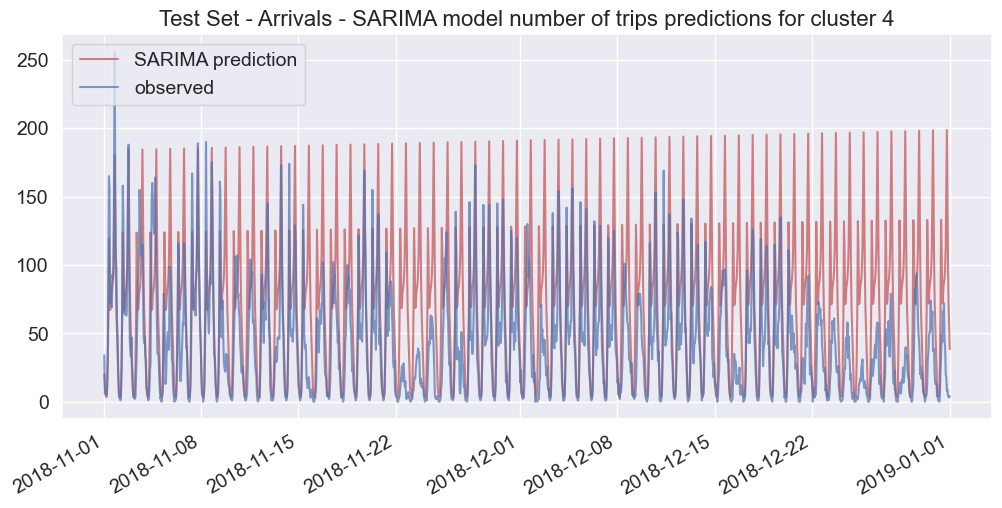

In [76]:
plotprediction(test_arrivals ,
    test_forecast_arrivals,
    labels=["observed", "SARIMA prediction"],
    title="Test Set - Arrivals - SARIMA model number of trips predictions for cluster 4")

In [77]:
print_stats(test_arrivals,test_forecast_arrivals, "SARIMA for Arrivals")

SARIMA for Arrivals: 
	r^2=-0.431393
	MSE=2222.651037
	MAE=32.652750
	MAPE=inf


### Training SARIMA model for departures 

We use the optimal parameters found after doing the grid search for the training data for arrivals

In [78]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
ps = 0
qs = 2
Ps = 2
Qs = 1

d = 0
D = 0
s = 24

val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask_departures = grouped_departures.index < val_start
val_mask_departures   = (grouped_departures.index >= val_start) & (grouped_departures.index < test_start)
test_mask_departures  = (grouped_departures.index >= test_start)& (grouped_departures.index < test_stop)

train_departures = grouped_departures[train_mask_departures].iloc[:, 0]
val_departures   = grouped_departures[val_mask_departures].iloc[:, 0]
test_departures  = grouped_departures[test_mask_departures].iloc[:, 0]

train_mask_all_departures = grouped_departures.index < test_start


train_all_departures = grouped_departures[train_mask_all_departures].iloc[:, 0]

model_sar_depar = SARIMAX(
            train_all_departures,
            order=(ps, d, qs),
            seasonal_order=(Ps, D, Qs, s),
            enforce_stationarity=False,     # prevent crashes
            enforce_invertibility=False,    # prevent crashes
            simple_differencing=True,       # reduces matrix size
            deprecation_warnings=False
        )

fit_sar_depar = model_sar_depar.fit(
            method="powell",    # most stable optimizer (never segfaults)
            disp=False
        )

test_forecast_departures = fit_sar_depar.forecast(steps=len(test_departures))

/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['deprecation_warnings']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


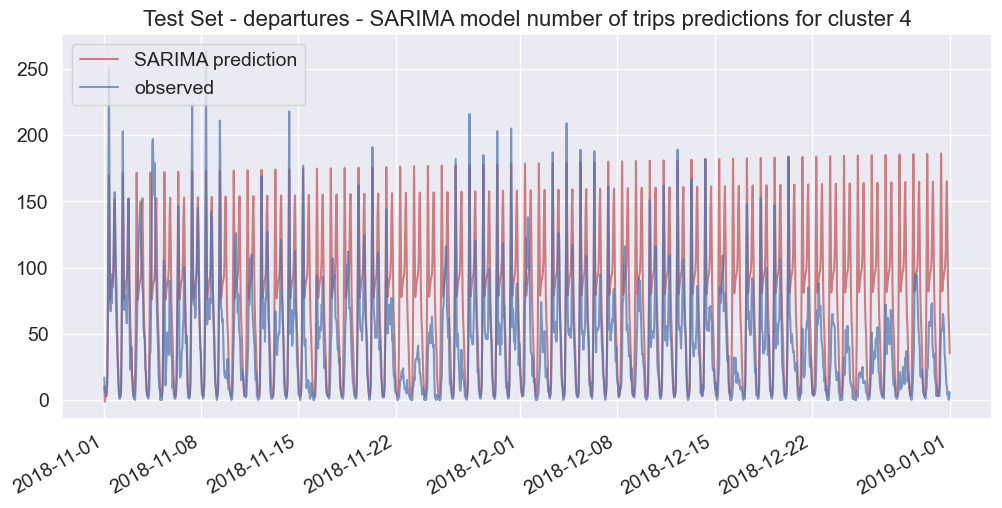

In [79]:
plotprediction(test_departures ,
    test_forecast_departures,
    labels=["observed", "SARIMA prediction"],
    title="Test Set - departures - SARIMA model number of trips predictions for cluster 4")

In [80]:
print_stats(test_departures,test_forecast_departures, "SARIMA for Arrivals")

SARIMA for Arrivals: 
	r^2=-0.377220
	MSE=2424.749502
	MAE=34.953981
	MAPE=inf


### Prediction for bike allocation

In [81]:
# Computing how many bikes to allocate given the observed arrivals and depatures based in the same policy 

# Computing the difference (diff):  predicted arrivals - departuresx
SARIMA_bike_alloc_pred = (test_forecast_arrivals - test_forecast_departures).to_frame(name="diff")

# Computing the accumulated sum of (diff)
SARIMA_bike_alloc_pred["daily_cumsum"] = SARIMA_bike_alloc_pred.groupby(SARIMA_bike_alloc_pred.index.date)["diff"].cumsum()

# For each day find the smallest accumlated sum 
min_daily_cumsum_pred = SARIMA_bike_alloc_pred.groupby(SARIMA_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min"),
)

# Assesing how many bike to allocate
min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: np.ceil(abs(x)) if x < 0 else 0)
)

# load the test set for bike allocation . 
min_daily_cumsum_test = pd.read_json("min_daily_cumsum_test_4.json")



In [82]:
print_stats(min_daily_cumsum_test["bikes_to_allocate"],min_daily_cumsum_pred["bikes_to_allocate"], "SARIMA bike allocation")

SARIMA bike allocation: 
	r^2=-1.672742
	MSE=6631.868852
	MAE=65.278689
	MAPE=231.539827


## Cluster 12

### Extracting Data for cluster 12

In [83]:
# Make sure starttime is a datetime
cluster_12_departures['starttime'] = pd.to_datetime(cluster_12_departures['starttime'])

# Extract date and hour
cluster_12_departures['date'] = cluster_12_departures['starttime'].dt.date
cluster_12_departures['hour'] = cluster_12_departures['starttime'].dt.hour


# Do the same for arrivals
cluster_12_arrivals['stoptime'] = pd.to_datetime(cluster_12_arrivals['stoptime'])

# Extract date and hour
cluster_12_arrivals['date'] = cluster_12_arrivals['stoptime'].dt.date
cluster_12_arrivals['hour'] = cluster_12_arrivals['stoptime'].dt.hour

In [84]:
grouped_arrivals = (
    cluster_12_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)

all_dates = np.unique(grouped_arrivals.index.date)
all_hours = pd.Index(range(24), name='hour')

full_index = pd.MultiIndex.from_product(
    [all_dates, all_hours],
    names = ['date', 'hour']
)

grouped_arrivals = (
    grouped_arrivals
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)


grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)

grouped_departures = (
    cluster_12_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_departures = (
    grouped_departures
        .set_index(['date', 'hour'])
        .reindex(full_index, fill_value=0)
        .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)


### Training SARIMA model for arrivals 

We use the optimal parameters found after doing the grid search for the training data for arrivals

In [85]:
ps = 0
qs = 2
Ps = 2
Qs = 1

d = 0
D = 0
s = 24

val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask_arrivals = grouped_arrivals.index < val_start
val_mask_arrivals   = (grouped_arrivals.index >= val_start) & (grouped_arrivals.index < test_start)
test_mask_arrivals  = (grouped_arrivals.index >= test_start)& (grouped_arrivals.index < test_stop)

train_arrivals = grouped_arrivals[train_mask_arrivals].iloc[:, 0]
val_arrivals   = grouped_arrivals[val_mask_arrivals].iloc[:, 0]
test_arrivals  = grouped_arrivals[test_mask_arrivals].iloc[:, 0]

train_mask_all_arrivals = grouped_arrivals.index < test_start


train_all_arrivals = grouped_arrivals[train_mask_all_arrivals].iloc[:, 0]

model_sar_arr = SARIMAX(
            train_all_arrivals,
            order=(ps, d, qs),
            seasonal_order=(Ps, D, Qs, s),
            enforce_stationarity=False,     # prevent crashes
            enforce_invertibility=False,    # prevent crashes
            simple_differencing=True,       # reduces matrix size
            deprecation_warnings=False
        )

fit_sar_arr = model_sar_arr.fit(
            method="powell",    # most stable optimizer (never segfaults)
            disp=False
        )

test_forecast_arrivals = fit_sar_arr.forecast(steps=len(test_arrivals))

/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['deprecation_warnings']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


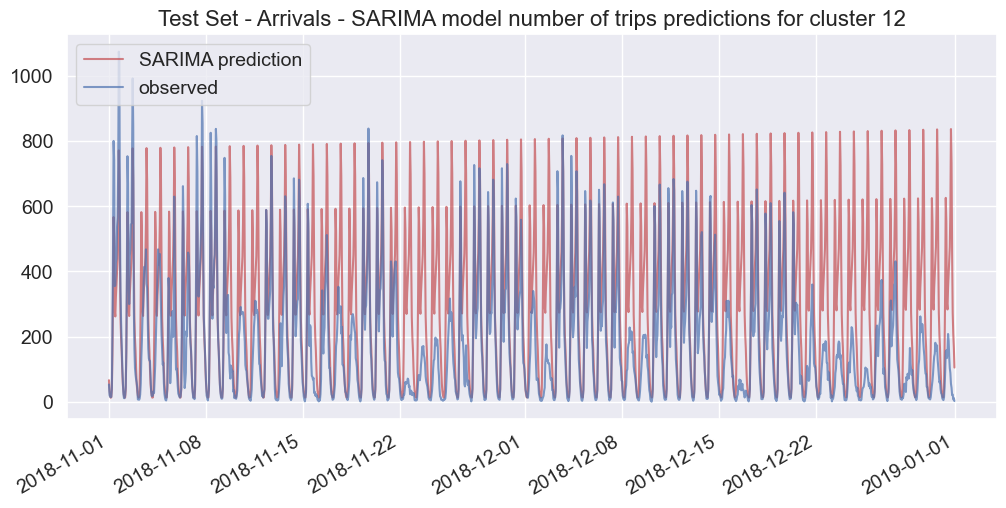

In [86]:
plotprediction(test_arrivals ,
    test_forecast_arrivals,
    labels=["observed", "SARIMA prediction"],
    title="Test Set - Arrivals - SARIMA model number of trips predictions for cluster 12")

In [87]:
print_stats(test_arrivals,test_forecast_arrivals, "SARIMA for Arrivals")

SARIMA for Arrivals: 
	r^2=-0.182057
	MSE=41637.779095
	MAE=133.068575
	MAPE=inf


### Training SARIMA model for departures 

We use the optimal parameters found after doing the grid search for the training data for arrivals

In [88]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
ps = 1
qs = 2
Ps = 1
Qs = 1

d = 0
D = 0
s = 24

val_start = pd.Timestamp("2018-10-01")
test_start = pd.Timestamp("2018-11-01")
test_stop = pd.Timestamp("2019-01-01")

train_mask_departures = grouped_departures.index < val_start
val_mask_departures   = (grouped_departures.index >= val_start) & (grouped_departures.index < test_start)
test_mask_departures  = (grouped_departures.index >= test_start)& (grouped_departures.index < test_stop)

train_departures = grouped_departures[train_mask_departures].iloc[:, 0]
val_departures   = grouped_departures[val_mask_departures].iloc[:, 0]
test_departures  = grouped_departures[test_mask_departures].iloc[:, 0]

train_mask_all_departures = grouped_departures.index < test_start


train_all_departures = grouped_departures[train_mask_all_departures].iloc[:, 0]

model_sar_depar = SARIMAX(
            train_all_departures,
            order=(ps, d, qs),
            seasonal_order=(Ps, D, Qs, s),
            enforce_stationarity=False,     # prevent crashes
            enforce_invertibility=False,    # prevent crashes
            simple_differencing=True,       # reduces matrix size
            deprecation_warnings=False
        )

fit_sar_depar = model_sar_depar.fit(
            method="powell",    # most stable optimizer (never segfaults)
            disp=False
        )

test_forecast_departures = fit_sar_depar.forecast(steps=len(test_departures))

/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/business-analytics2/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['deprecation_warnings']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


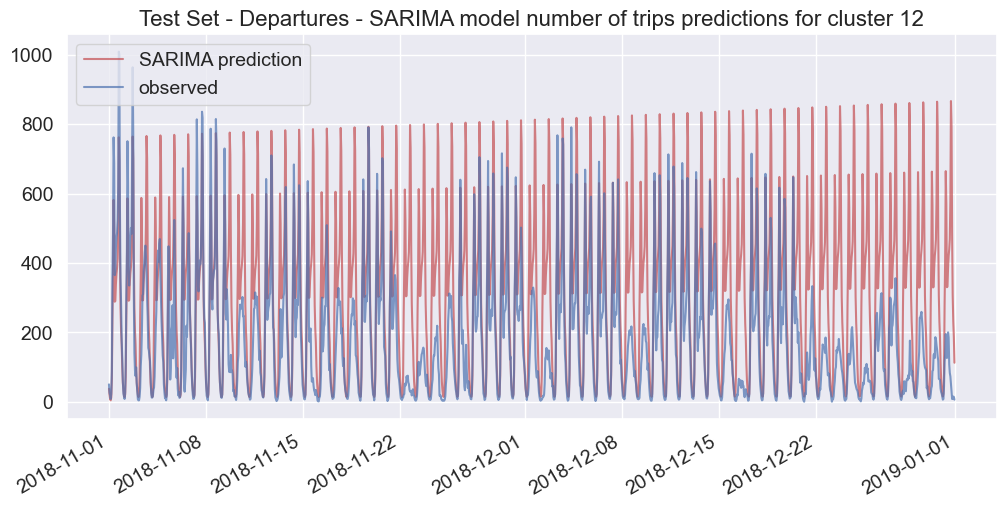

In [89]:
plotprediction(test_departures ,
    test_forecast_departures,
    labels=["observed", "SARIMA prediction"],
    title="Test Set - Departures - SARIMA model number of trips predictions for cluster 12")

In [90]:
print_stats(test_departures,test_forecast_departures, "SARIMA for departures")

SARIMA for departures: 
	r^2=-0.479089
	MSE=47820.713473
	MAE=148.579198
	MAPE=inf


### Prediction for bike allocation

In [91]:
# Computing how many bikes to allocate given the observed arrivals and depatures based in the same policy 

# Computing the difference (diff):  predicted arrivals - departuresx
SARIMA_bike_alloc_pred = (test_forecast_arrivals - test_forecast_departures).to_frame(name="diff")

# Computing the accumulated sum of (diff)
SARIMA_bike_alloc_pred["daily_cumsum"] = SARIMA_bike_alloc_pred.groupby(SARIMA_bike_alloc_pred.index.date)["diff"].cumsum()

# For each day find the smallest accumlated sum 
min_daily_cumsum_pred = SARIMA_bike_alloc_pred.groupby(SARIMA_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min"),
)

# Assesing how many bike to allocate
min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: np.ceil(abs(x)) if x < 0 else 0)
)

# load the test set for bike allocation . 
min_daily_cumsum_test = pd.read_json("min_daily_cumsum_test_12.json")



In [92]:
print_stats(min_daily_cumsum_test["bikes_to_allocate"],min_daily_cumsum_pred["bikes_to_allocate"], "SARIMA bike allocation")

SARIMA bike allocation: 
	r^2=-5.836910
	MSE=65500.278689
	MAE=202.245902
	MAPE=260.925616


# Random Forest Prediction Model 

## Cluster 4 

### Extracting data for cluster 4

In [93]:
cluster_4_departures = df_merged_start[df_merged_start["cluster"] == 4].copy()
cluster_4_arrivals = df_merged_end[df_merged_end['cluster'] == 4].copy()
cluster_4_departures.size, cluster_4_arrivals.size

# Make sure starttime is a datetime
cluster_4_arrivals['stoptime'] = pd.to_datetime(cluster_4_arrivals['stoptime'])

# Extract date and hour
cluster_4_arrivals['date'] = cluster_4_arrivals['stoptime'].dt.date
cluster_4_arrivals['hour'] = cluster_4_arrivals['stoptime'].dt.hour

# Make sure starttime is a datetime
cluster_4_departures['starttime'] = pd.to_datetime(cluster_4_departures['starttime'])

# Extract date and hour
cluster_4_departures['date'] = cluster_4_departures['starttime'].dt.date
cluster_4_departures['hour'] = cluster_4_departures['starttime'].dt.hour

In [94]:


# Make sure starttime is a datetime
cluster_4_arrivals['stoptime'] = pd.to_datetime(cluster_4_arrivals['stoptime'])

# Extract date and hour
cluster_4_arrivals['date'] = cluster_4_arrivals['stoptime'].dt.date
cluster_4_arrivals['hour'] = cluster_4_arrivals['stoptime'].dt.hour

grouped_arrivals = (
    cluster_4_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)
grouped_arrivals

grouped_departures = (
    cluster_4_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)

### Random Forest Regressor - Arrivals

In [95]:
from sklearn.ensemble import RandomForestRegressor

# --- Create lag features for 24, 48, 72 hours ---
for lag in [24, 25, 26, 27, 28, 48, 72, 166, 167, 168, 169, 170, 171]:
    grouped_arrivals[f'lag_{lag}'] = grouped_arrivals['trip_count'].shift(lag)

# --- Calendar / time features from the datetime index ---
grouped_arrivals['hour']  = grouped_arrivals.index.hour
grouped_arrivals['dow']   = grouped_arrivals.index.weekday   # 0=Mon,...,6=Sun
grouped_arrivals['month'] = grouped_arrivals.index.month

# One-hot encode categorical variables (user type and gender)
grouped_rf_arrivals = pd.get_dummies(
    grouped_arrivals,
    columns=['most_common_user_type', 'most_common_gender'],
    drop_first=True
)


# Drop first rows where lag features are NaN (because of shifting)
grouped_rf_arrivals = grouped_rf_arrivals.dropna(subset=['lag_24', 'lag_48', 'lag_72', 'lag_171'])

train_mask_rf = grouped_rf_arrivals.index < test_start
test_mask_rf  = (grouped_rf_arrivals.index >= test_start) & (grouped_rf_arrivals.index < test_end)

# Define feature columns (exclude target and naive copy column)
feature_cols_arrivals = [
    c for c in grouped_rf_arrivals.columns 
    if c not in ['trip_count']  
]

# Train and Test data 
X_train_arrivals = grouped_rf_arrivals.loc[train_mask_rf, feature_cols_arrivals]
y_train_arrivals = grouped_rf_arrivals.loc[train_mask_rf, 'trip_count']

X_test_arrivals  = grouped_rf_arrivals.loc[test_mask_rf, feature_cols_arrivals]
y_test_arrivals  = grouped_rf_arrivals.loc[test_mask_rf, 'trip_count']

# Creating random forrest model 
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Fit model 
rf.fit(X_train_arrivals, y_train_arrivals)

# Make predictions
y_pred_rf_arrivals = rf.predict(X_test_arrivals)

# Evaluate model 
print("===TRAINING SET STATS===")
print_stats(y_train_arrivals, rf.predict(X_train_arrivals), "Random Forest (lags 24/48/72) – arrivals, cluster 4")
print("===TEST SET STATS===")
print_stats(y_test_arrivals, y_pred_rf_arrivals, "Random Forest (lags 24/48/72) – arrivals, cluster 4")

===TRAINING SET STATS===
Random Forest (lags 24/48/72) – arrivals, cluster 4: 
	r^2=0.970295
	MSE=76.593179
	MAE=5.503681
	MAPE=21.642646
===TEST SET STATS===
Random Forest (lags 24/48/72) – arrivals, cluster 4: 
	r^2=0.532639
	MSE=720.765003
	MAE=18.639851
	MAPE=125.888872


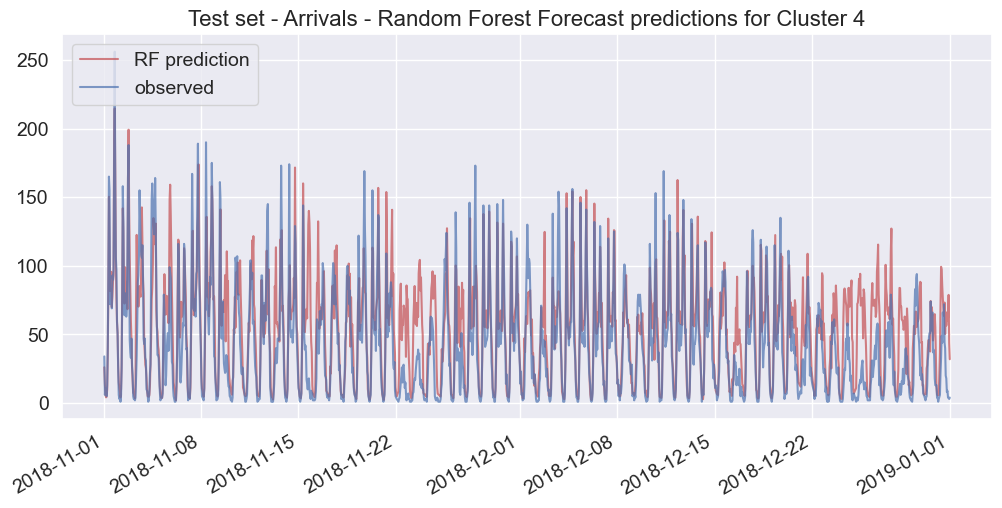

In [96]:
# Convert predictions to series for plotting
y_pred_rf_arrivals = pd.Series(rf.predict(X_test_arrivals), index=X_test_arrivals.index, name="y_pred_rf")
y_test_arrivals = pd.Series(y_test_arrivals, index=X_test_arrivals.index, name="y_test")

# Plottint prediction and actual trips.
plotprediction(
    series = y_test_arrivals,
    pred_series = y_pred_rf_arrivals,
    labels = ['observed', 'RF prediction'],
    title = "Test set - Arrivals - Random Forest Forecast predictions for Cluster 4")

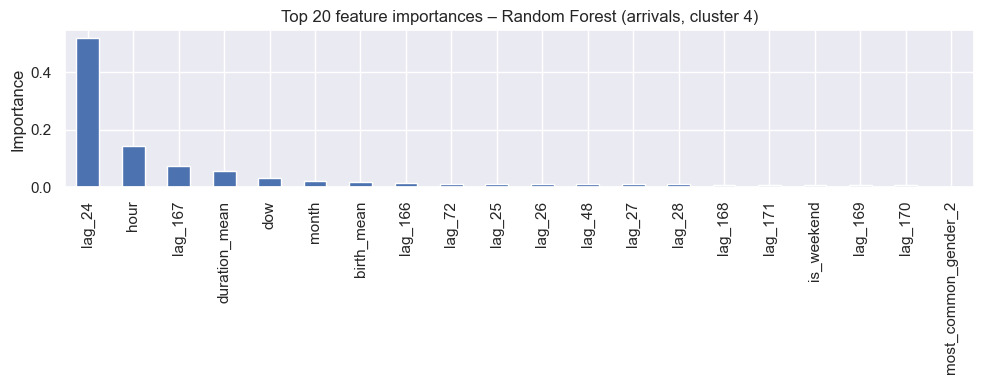

lag_168                 0.009702
lag_24                  0.519623
lag_72                  0.013149
most_common_gender_1    0.000011
dtype: float64


In [97]:
# Find and plot most important features 
importances = pd.Series(rf.feature_importances_, index=feature_cols_arrivals)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (arrivals, cluster 4)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['lag_168', 'lag_24', 'lag_72', 'most_common_gender_1']])

### Random Forest Regressor - Departures 

In [98]:
# --- Create lag features for 24, 48, 72 hours ---
for lag in [24, 25, 26, 27, 28, 48, 72, 166, 167, 168, 169, 170, 171]:
    grouped_departures[f'lag_{lag}'] = grouped_departures['trip_count'].shift(lag)

# --- Calendar / time features from the datetime index ---
grouped_departures['hour']  = grouped_departures.index.hour
grouped_departures['dow']   = grouped_departures.index.weekday   # 0=Mon,...,6=Sun
grouped_departures['month'] = grouped_departures.index.month

# One-hot encode categorical variables (user type and gender)
grouped_rf_departures = pd.get_dummies(
    grouped_departures,
    columns=['most_common_user_type', 'most_common_gender'],
    drop_first=True
)

# Drop first rows where lag features are NaN (because of shifting)
grouped_rf_departures = grouped_rf_departures.dropna(subset=['lag_24', 'lag_48', 'lag_72', 'lag_171'])

train_mask_rf = grouped_rf_departures.index < test_start
test_mask_rf  = (grouped_rf_departures.index >= test_start) & (grouped_rf_departures.index < test_end)

# Define feature columns (exclude target and naive copy column)
feature_cols_departures = [
    c for c in grouped_rf_departures.columns 
    if c not in ['trip_count']  # 'copy_pred' exists from the naive model
]

# Train and test data 
X_train_departures = grouped_rf_departures.loc[train_mask_rf, feature_cols_departures]
y_train_departures = grouped_rf_departures.loc[train_mask_rf, 'trip_count']

X_test_departures  = grouped_rf_departures.loc[test_mask_rf, feature_cols_departures]
y_test_departures  = grouped_rf_departures.loc[test_mask_rf, 'trip_count']

# Creation of model 
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Fit of model 
rf.fit(X_train_departures, y_train_departures)

# Prediction
y_pred_rf_departures = rf.predict(X_test_departures)

# Evaluation of prediction
print("===TRAINING SET STATS===")
print_stats(y_train_departures, rf.predict(X_train_departures), "Random Forest (lags 24/48/72) – departures, cluster 4")
print("===TEST SET STATS===")
print_stats(y_test_departures, y_pred_rf_departures, "Random Forest (lags 24/48/72) – departures, cluster 4")


===TRAINING SET STATS===
Random Forest (lags 24/48/72) – departures, cluster 4: 
	r^2=0.970897
	MSE=80.556371
	MAE=5.605370
	MAPE=20.979151
===TEST SET STATS===
Random Forest (lags 24/48/72) – departures, cluster 4: 
	r^2=0.602742
	MSE=696.568111
	MAE=18.146827
	MAPE=113.474466


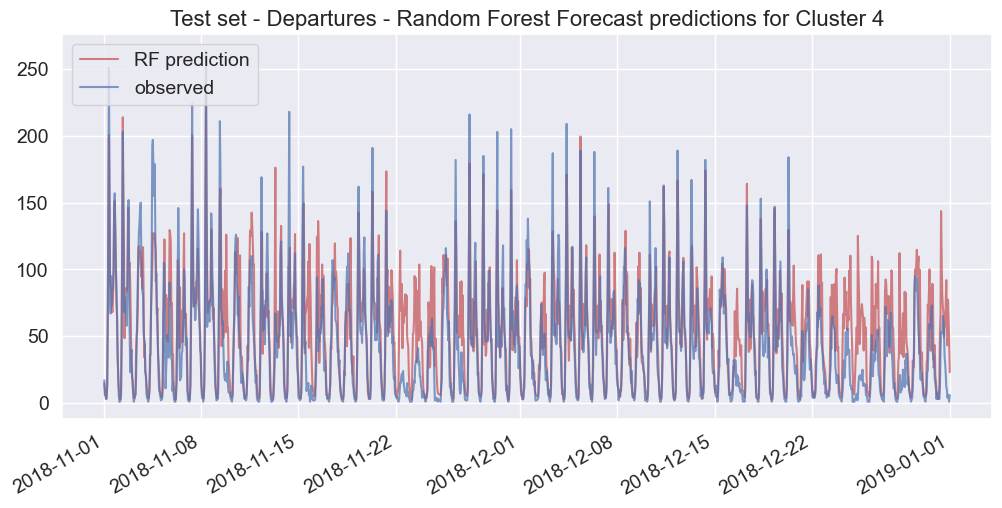

In [99]:
# Convert into series to plot
y_pred_rf_departures = pd.Series(rf.predict(X_test_departures), index=X_test_departures.index, name="y_pred_rf")
y_test_departures = pd.Series(y_test_departures, index=X_test_departures.index, name="y_test")

# Plot predicted trip count vs observed trip count
plotprediction(
    series = y_test_departures,
    pred_series = y_pred_rf_departures,
    labels = ['observed', 'RF prediction'],
    title = "Test set - Departures - Random Forest Forecast predictions for Cluster 4"
)

In [100]:
len(y_test_departures), len(y_pred_rf_departures)

(1420, 1420)

### Prediction for bike allocation 

In [101]:
# Convert to series 
y_pred_rf_arrivals = pd.Series(y_pred_rf_arrivals, index=X_test_arrivals.index)
y_pred_rf_departures = pd.Series(y_pred_rf_departures, index=X_test_departures.index)

# Compute difference: arrivals - departues 
rf_bike_alloc_pred = (y_pred_rf_arrivals - y_pred_rf_departures).to_frame(name="diff")

# Find NAN indexes because of missing time stamps 
nan_indexes = rf_bike_alloc_pred[rf_bike_alloc_pred.isna().any(axis=1)].index
nan_indexes

DatetimeIndex(['2018-11-03 05:00:00', '2018-11-05 01:00:00',
               '2018-11-06 01:00:00', '2018-11-07 03:00:00',
               '2018-11-08 03:00:00', '2018-11-10 04:00:00',
               '2018-11-15 03:00:00', '2018-11-18 05:00:00',
               '2018-11-20 03:00:00', '2018-11-23 02:00:00',
               '2018-11-23 03:00:00', '2018-11-23 05:00:00',
               '2018-11-24 02:00:00', '2018-11-24 03:00:00',
               '2018-11-24 05:00:00', '2018-11-24 22:00:00',
               '2018-11-25 05:00:00', '2018-11-27 03:00:00',
               '2018-11-27 04:00:00', '2018-12-02 02:00:00',
               '2018-12-02 03:00:00', '2018-12-04 02:00:00',
               '2018-12-07 03:00:00', '2018-12-10 02:00:00',
               '2018-12-10 03:00:00', '2018-12-11 03:00:00',
               '2018-12-15 04:00:00', '2018-12-15 05:00:00',
               '2018-12-16 03:00:00', '2018-12-19 04:00:00',
               '2018-12-20 03:00:00', '2018-12-20 04:00:00',
               '2018-12-

In [102]:
# Allocating the correct difference in indexes with NAN 
for ts in nan_indexes:
    # If arrivals has a prediction for this timestamp
    if ts in y_pred_rf_arrivals.index:
        rf_bike_alloc_pred.loc[ts] = y_pred_rf_arrivals.loc[ts]
    else:
        # If not, fall back to negative departures
        rf_bike_alloc_pred.loc[ts] = -y_pred_rf_departures.loc[ts]

In [103]:
# Compute the accumulated sum of the difference
rf_bike_alloc_pred["daily_cumsum"] = rf_bike_alloc_pred.groupby(rf_bike_alloc_pred.index.date)["diff"].cumsum()

# Find minimum of accumulated sum 
min_daily_cumsum_pred = rf_bike_alloc_pred.groupby(rf_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

# Assensing how many bike to allocate 
min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: np.ceil(abs(x)) if x < 0 else 0)
)

min_daily_cumsum_pred

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-133.528518,134.0
2018-11-02,-171.778254,172.0
2018-11-03,-5.893721,6.0
2018-11-04,-128.461032,129.0
2018-11-05,-58.981185,59.0
...,...,...
2018-12-27,-55.191147,56.0
2018-12-28,-22.325014,23.0
2018-12-29,-265.387018,266.0
2018-12-30,-228.730005,229.0


In [104]:
# Loading test set of how many bike to allocate 
min_daily_cumsum_test = pd.read_json("min_daily_cumsum_test_4.json")
min_daily_cumsum_test

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-187,187
2018-11-02,-122,122
2018-11-03,-85,85
2018-11-04,-146,146
2018-11-05,-94,94
...,...,...
2018-12-27,-80,80
2018-12-28,-26,26
2018-12-29,-81,81
2018-12-30,-50,50


In [105]:
# Evaluating the bike allocation model 

print_stats(min_daily_cumsum_test["bikes_to_allocate"], min_daily_cumsum_pred["bikes_to_allocate"], title="Evaluation of Random Forest bike allocation for cluster 4")

Evaluation of Random Forest bike allocation for cluster 4: 
	r^2=-1.021153
	MSE=5015.081967
	MAE=48.393443
	MAPE=88.488887


## Cluster 12

### Extracting data for cluster 12

In [106]:
cluster_12_departures = df_merged_start[df_merged_start["cluster"] == 12].copy()
cluster_12_arrivals = df_merged_end[df_merged_end['cluster'] == 12].copy()
cluster_12_departures.size, cluster_12_arrivals.size

# Make sure starttime is a datetime
cluster_12_arrivals['stoptime'] = pd.to_datetime(cluster_12_arrivals['stoptime'])

# Extract date and hour
cluster_12_arrivals['date'] = cluster_12_arrivals['stoptime'].dt.date
cluster_12_arrivals['hour'] = cluster_12_arrivals['stoptime'].dt.hour

# Make sure starttime is a datetime
cluster_12_departures['starttime'] = pd.to_datetime(cluster_12_departures['starttime'])

# Extract date and hour
cluster_12_departures['date'] = cluster_12_departures['starttime'].dt.date
cluster_12_departures['hour'] = cluster_12_departures['starttime'].dt.hour

In [107]:


# Make sure starttime is a datetime
cluster_12_arrivals['stoptime'] = pd.to_datetime(cluster_12_arrivals['stoptime'])

# Extract date and hour
cluster_12_arrivals['date'] = cluster_12_arrivals['stoptime'].dt.date
cluster_12_arrivals['hour'] = cluster_12_arrivals['stoptime'].dt.hour

grouped_arrivals = (
    cluster_12_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)
grouped_arrivals

grouped_departures = (
    cluster_12_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)

### Random Forest Regressor - Arrivals

In [108]:
from sklearn.ensemble import RandomForestRegressor

# --- Create lag features for 24, 48, 72 hours ---
for lag in [24, 25, 26, 27, 28, 48, 72, 166, 167, 168, 169, 170, 171]:
    grouped_arrivals[f'lag_{lag}'] = grouped_arrivals['trip_count'].shift(lag)

# --- Calendar / time features from the datetime index ---
grouped_arrivals['hour']  = grouped_arrivals.index.hour
grouped_arrivals['dow']   = grouped_arrivals.index.weekday   # 0=Mon,...,6=Sun
grouped_arrivals['month'] = grouped_arrivals.index.month

# One-hot encode categorical variables (user type and gender)
grouped_rf_arrivals = pd.get_dummies(
    grouped_arrivals,
    columns=['most_common_user_type', 'most_common_gender'],
    drop_first=True
)


# Drop first rows where lag features are NaN (because of shifting)
grouped_rf_arrivals = grouped_rf_arrivals.dropna(subset=['lag_24', 'lag_48', 'lag_72', 'lag_171'])

train_mask_rf = grouped_rf_arrivals.index < test_start
test_mask_rf  = (grouped_rf_arrivals.index >= test_start) & (grouped_rf_arrivals.index < test_end)

# Define feature columns (exclude target and naive copy column)
feature_cols_arrivals = [
    c for c in grouped_rf_arrivals.columns 
    if c not in ['trip_count']  
]

# Train and Test data 
X_train_arrivals = grouped_rf_arrivals.loc[train_mask_rf, feature_cols_arrivals]
y_train_arrivals = grouped_rf_arrivals.loc[train_mask_rf, 'trip_count']

X_test_arrivals  = grouped_rf_arrivals.loc[test_mask_rf, feature_cols_arrivals]
y_test_arrivals  = grouped_rf_arrivals.loc[test_mask_rf, 'trip_count']

# Creating random forrest model 
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Fit model 
rf.fit(X_train_arrivals, y_train_arrivals)

# Make predictions
y_pred_rf_arrivals = rf.predict(X_test_arrivals)

# Evaluate model 
print("===TRAINING SET STATS===")
print_stats(y_train_arrivals, rf.predict(X_train_arrivals), "Random Forest (lags 24/48/72) – arrivals, cluster 12")
print("===TEST SET STATS===")
print_stats(y_test_arrivals, y_pred_rf_arrivals, "Random Forest (lags 24/48/72) – arrivals, cluster 12")

===TRAINING SET STATS===
Random Forest (lags 24/48/72) – arrivals, cluster 12: 
	r^2=0.976200
	MSE=1287.231468
	MAE=19.330510
	MAPE=20.416451
===TEST SET STATS===
Random Forest (lags 24/48/72) – arrivals, cluster 12: 
	r^2=0.745760
	MSE=8955.876077
	MAE=54.368897
	MAPE=84.437050


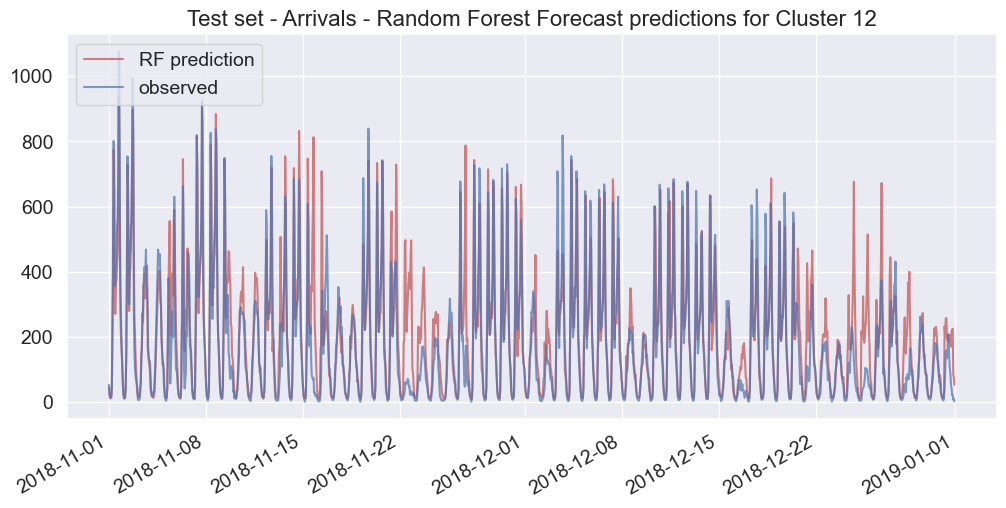

In [109]:
# Convert predictions to series for plotting
y_pred_rf_arrivals = pd.Series(rf.predict(X_test_arrivals), index=X_test_arrivals.index, name="y_pred_rf")
y_test_arrivals = pd.Series(y_test_arrivals, index=X_test_arrivals.index, name="y_test")

# Plottint prediction and actual trips.
plotprediction(
    series = y_test_arrivals,
    pred_series = y_pred_rf_arrivals,
    labels = ['observed', 'RF prediction'],
    title = "Test set - Arrivals - Random Forest Forecast predictions for Cluster 12")

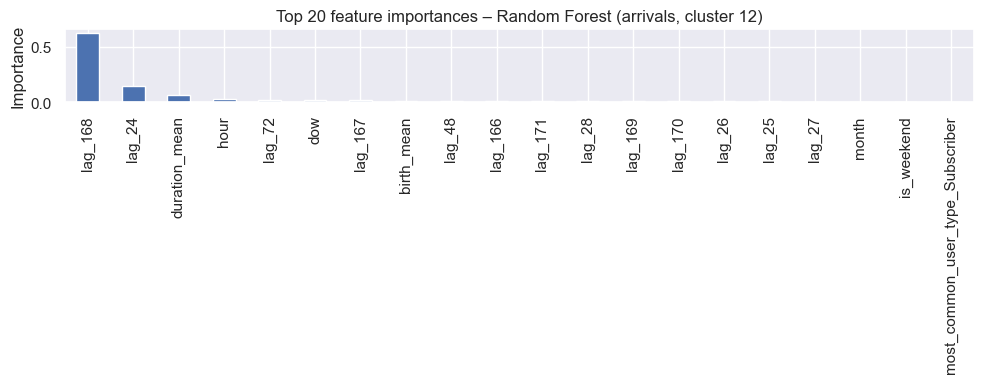

lag_168                 6.260074e-01
lag_24                  1.491726e-01
lag_72                  2.139521e-02
most_common_gender_1    4.913708e-07
dtype: float64


In [110]:
# Find and plot most important features 
importances = pd.Series(rf.feature_importances_, index=feature_cols_arrivals)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (arrivals, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['lag_168', 'lag_24', 'lag_72', 'most_common_gender_1']])

### Random Forest Regressor - Departures 

In [177]:
# --- Create lag features for 24, 48, 72 hours ---
for lag in [24, 25, 26, 27, 28, 48, 72, 166, 167, 168, 169, 170, 171]:
    grouped_departures[f'lag_{lag}'] = grouped_departures['trip_count'].shift(lag)

# --- Calendar / time features from the datetime index ---
grouped_departures['hour']  = grouped_departures.index.hour
grouped_departures['dow']   = grouped_departures.index.weekday   # 0=Mon,...,6=Sun
grouped_departures['month'] = grouped_departures.index.month

# One-hot encode categorical variables (user type and gender)
grouped_rf_departures = pd.get_dummies(
    grouped_departures,
    columns=['most_common_user_type', 'most_common_gender'],
    drop_first=True
)

# Drop first rows where lag features are NaN (because of shifting)
grouped_rf_departures = grouped_rf_departures.dropna(subset=['lag_24', 'lag_48', 'lag_72', 'lag_171'])

train_mask_rf = grouped_rf_departures.index < test_start
test_mask_rf  = (grouped_rf_departures.index >= test_start) & (grouped_rf_departures.index < test_end)

# Define feature columns (exclude target and naive copy column)
feature_cols_departures = [
    c for c in grouped_rf_departures.columns 
    if c not in ['trip_count']  # 'copy_pred' exists from the naive model
]

# Train and test data 
X_train_departures = grouped_rf_departures.loc[train_mask_rf, feature_cols_departures]
y_train_departures = grouped_rf_departures.loc[train_mask_rf, 'trip_count']

X_test_departures  = grouped_rf_departures.loc[test_mask_rf, feature_cols_departures]
y_test_departures  = grouped_rf_departures.loc[test_mask_rf, 'trip_count']

# Creation of model 
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Fit of model 
rf.fit(X_train_departures, y_train_departures)

# Prediction
y_pred_rf_departures = rf.predict(X_test_departures)

# Evaluation of prediction
# print("===TRAINING SET STATS===")
print_stats(y_train_departures, rf.predict(X_train_departures), "TRAIN (baseline)")
# print("===TEST SET STATS===")
print_stats(y_test_departures, y_pred_rf_departures, "TEST (baseline)")


TRAIN (baseline): 
	r^2=0.976879
	MSE=1169.847370
	MAE=19.085983
	MAPE=19.501890
TEST (baseline): 
	r^2=0.718529
	MSE=9099.828979
	MAE=55.828667
	MAPE=88.882412


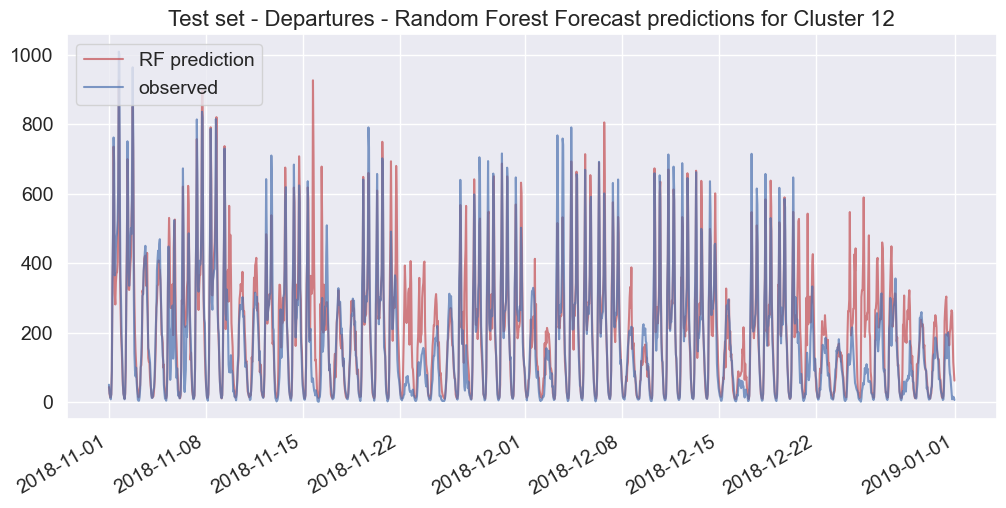

In [112]:
# Convert into series to plot
y_pred_rf_departures = pd.Series(rf.predict(X_test_departures), index=X_test_departures.index, name="y_pred_rf")
y_test_departures = pd.Series(y_test_departures, index=X_test_departures.index, name="y_test")

# Plot predicted trip count vs observed trip count
plotprediction(
    series = y_test_departures,
    pred_series = y_pred_rf_departures,
    labels = ['observed', 'RF prediction'],
    title = "Test set - Departures - Random Forest Forecast predictions for Cluster 12"
)

### Prediction for bike allocation 

In [113]:
# Convert to series 
y_pred_rf_arrivals = pd.Series(y_pred_rf_arrivals, index=X_test_arrivals.index)
y_pred_rf_departures = pd.Series(y_pred_rf_departures, index=X_test_departures.index)

# Compute difference: arrivals - departues 
rf_bike_alloc_pred = (y_pred_rf_arrivals - y_pred_rf_departures).to_frame(name="diff")

# Find NAN indexes because of missing time stamps 
nan_indexes = rf_bike_alloc_pred[rf_bike_alloc_pred.isna().any(axis=1)].index
nan_indexes

DatetimeIndex(['2018-12-10 03:00:00', '2018-12-21 03:00:00',
               '2018-12-23 03:00:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)

In [114]:
# Allocating the correct difference in indexes with NAN 
for ts in nan_indexes:
    # If arrivals has a prediction for this timestamp
    if ts in y_pred_rf_arrivals.index:
        rf_bike_alloc_pred.loc[ts] = y_pred_rf_arrivals.loc[ts]
    else:
        # If not, fall back to negative departures
        rf_bike_alloc_pred.loc[ts] = -y_pred_rf_departures.loc[ts]

In [115]:
# Compute the accumulated sum of the difference
rf_bike_alloc_pred["daily_cumsum"] = rf_bike_alloc_pred.groupby(rf_bike_alloc_pred.index.date)["diff"].cumsum()

# Find minimum of accumulated sum 
min_daily_cumsum_pred = rf_bike_alloc_pred.groupby(rf_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)

# Assensing how many bike to allocate 
min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: np.ceil(abs(x)) if x < 0 else 0)
)

min_daily_cumsum_pred

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-254.601368,255.0
2018-11-02,-268.951927,269.0
2018-11-03,-447.758756,448.0
2018-11-04,-317.132511,318.0
2018-11-05,-366.756598,367.0
...,...,...
2018-12-27,-314.115538,315.0
2018-12-28,-377.432960,378.0
2018-12-29,-314.141825,315.0
2018-12-30,-162.487045,163.0


In [116]:
# Loading test set of how many bike to allocate 
min_daily_cumsum_test = pd.read_json("min_daily_cumsum_test_12.json")
min_daily_cumsum_test

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-212,212
2018-11-02,-235,235
2018-11-03,-186,186
2018-11-04,-198,198
2018-11-05,-298,298
...,...,...
2018-12-27,-248,248
2018-12-28,-40,40
2018-12-29,-198,198
2018-12-30,-72,72


In [117]:
# Evaluating the bike allocation model 

print_stats(min_daily_cumsum_test["bikes_to_allocate"], min_daily_cumsum_pred["bikes_to_allocate"], title="Evaluation of Random Forest bike allocation for cluster 12")

Evaluation of Random Forest bike allocation for cluster 12: 
	r^2=-4.696565
	MSE=54575.327869
	MAE=158.377049
	MAPE=129.522176


# Exploratory Component

## Impact of Weather and Holidays on bike demand seen in departures

In [118]:
# === Load NYC weather data ===
weather = pd.read_csv("nyc_weather_2018.csv")

# Inspect columns if you want
print(weather.columns)
weather.head()


Index(['temperature_2m (°C)', 'precipitation (mm)', 'rain (mm)',
       'cloudcover (%)', 'cloudcover_low (%)', 'cloudcover_mid (%)',
       'cloudcover_high (%)', 'windspeed_10m (km/h)', 'winddirection_10m (°)'],
      dtype='object')


,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
0,-11.1,0.0,0.0,0.0,0.0,0.0,0.0,9.4,302.0
1,-11.5,0.0,0.0,0.0,0.0,0.0,0.0,10.1,297.0
2,-11.8,0.0,0.0,0.0,0.0,0.0,0.0,12.3,302.0
3,-12.2,0.0,0.0,0.0,0.0,0.0,0.0,13.9,307.0
4,-12.2,0.0,0.0,0.0,0.0,0.0,0.0,14.3,309.0


In [119]:
# Create an hourly datetime index for 2018
weather['datetime'] = pd.date_range(
    start='2018-01-01 00:00',
    periods=len(weather),
    freq='h'
)
weather = weather.set_index('datetime')


In [120]:
# Join weather data on the datetime index
grouped_rf_departures_weather = grouped_rf_departures.join(weather, how='left')

grouped_rf_departures_weather.head()


,trip_count,is_weekend,duration_mean,birth_mean,lag_24,lag_25,lag_26,lag_27,lag_28,lag_48,...,most_common_gender_2,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-08 09:00:00,238,False,732.054622,1978.722689,22.0,7.0,10.0,2.0,2.0,14.0,...,False,-8.7,0.0,0.0,2.0,2.0,1.0,0.0,13.6,220.0
2018-01-08 10:00:00,72,False,1214.875000,1977.694444,24.0,22.0,7.0,10.0,2.0,16.0,...,False,-9.1,0.0,0.0,24.0,3.0,15.0,42.0,10.5,218.0
2018-01-08 11:00:00,67,False,1014.432836,1976.462687,35.0,24.0,22.0,7.0,10.0,21.0,...,False,-9.1,0.0,0.0,50.0,3.0,50.0,59.0,10.3,216.0
2018-01-08 12:00:00,58,False,593.189655,1976.120690,35.0,35.0,24.0,22.0,7.0,30.0,...,False,-9.1,0.0,0.0,39.0,3.0,61.0,0.0,9.0,217.0
2018-01-08 13:00:00,85,False,615.941176,1976.600000,54.0,35.0,35.0,24.0,22.0,28.0,...,False,-8.8,0.0,0.0,63.0,2.0,65.0,73.0,7.9,204.0


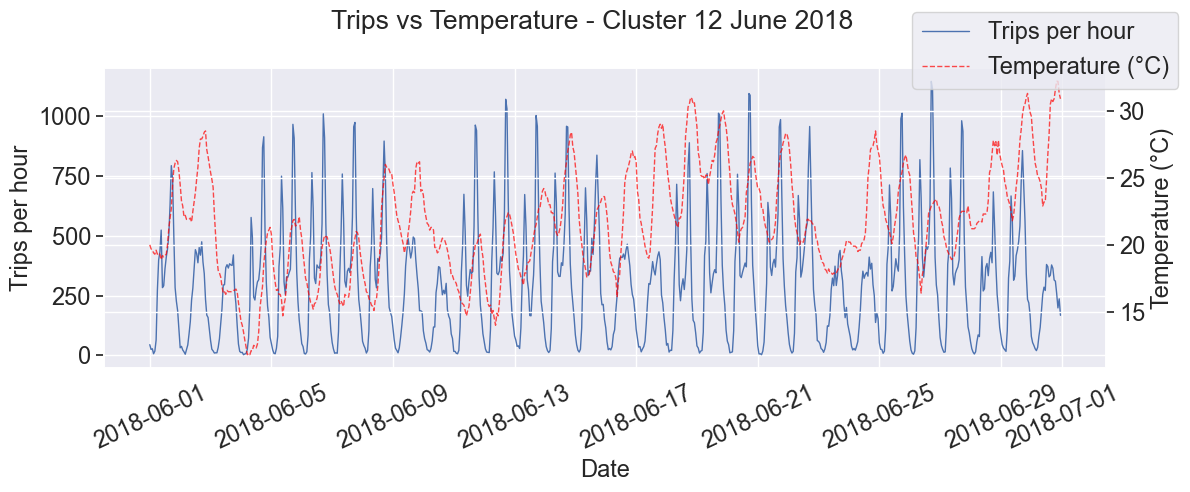

In [121]:
# Pick a month to visualize
start, end = '2018-06-01', '2018-07-01'
mask = (grouped_rf_departures_weather.index >= start) & (grouped_rf_departures_weather.index < end)
data_month = grouped_rf_departures_weather.loc[mask]

fig, ax1 = plt.subplots(figsize=(12,5))

# Trips (left axis)
ax1.plot(data_month.index, data_month['trip_count'], label='Trips per hour', linewidth=1)
plt.xticks(rotation=25)
ax1.set_xlabel('Date')
ax1.set_ylabel('Trips per hour')
ax1.tick_params(axis='y')
simple_set_font_size(ax1, 17, 20)

# Temperature (right axis)
ax2 = ax1.twinx()
ax2.plot(data_month.index, data_month['temperature_2m (°C)'], label='Temperature (°C)', linewidth=1, alpha=0.7, linestyle='--', color='red')
ax2.set_ylabel('Temperature (°C)')
ax2.tick_params(axis='y')
simple_set_font_size(ax2, 17, 19)

# Title + legend
fig.suptitle('Trips vs Temperature - Cluster 12 June 2018', fontsize=19)
fig.tight_layout()
fig.legend(loc='upper right')

plt.show()


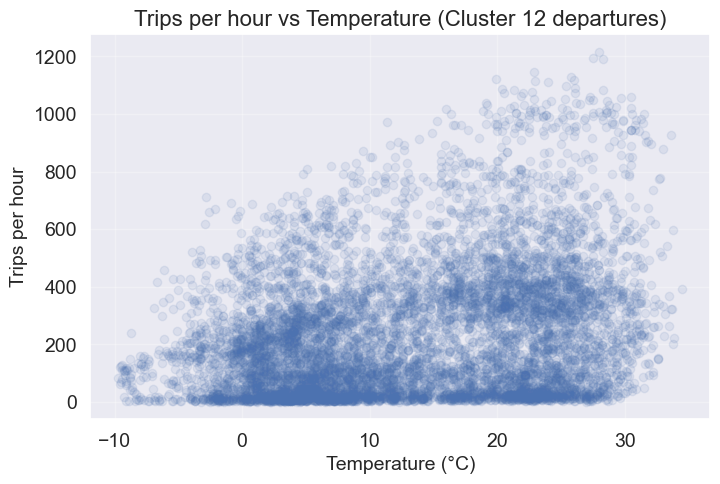

In [122]:
sample = grouped_rf_departures_weather[['trip_count', 'temperature_2m (°C)']].dropna()

plt.figure(figsize=(8,5))
plt.scatter(sample['temperature_2m (°C)'], sample['trip_count'], alpha=0.1)
plt.xlabel('Temperature (°C)')
plt.ylabel('Trips per hour')
plt.title('Trips per hour vs Temperature (Cluster 12 departures)')
simple_set_font_size(plt.gca(), labelsize=14, titlesize=16)
plt.grid(alpha=0.3)
plt.show()


/var/folders/2q/0s6yfy4s7cdcl3184vyy5v_w0000gp/T/ipykernel_8394/1049173978.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_trips_by_temp = sample.groupby(temp_bin)['trip_count'].mean()


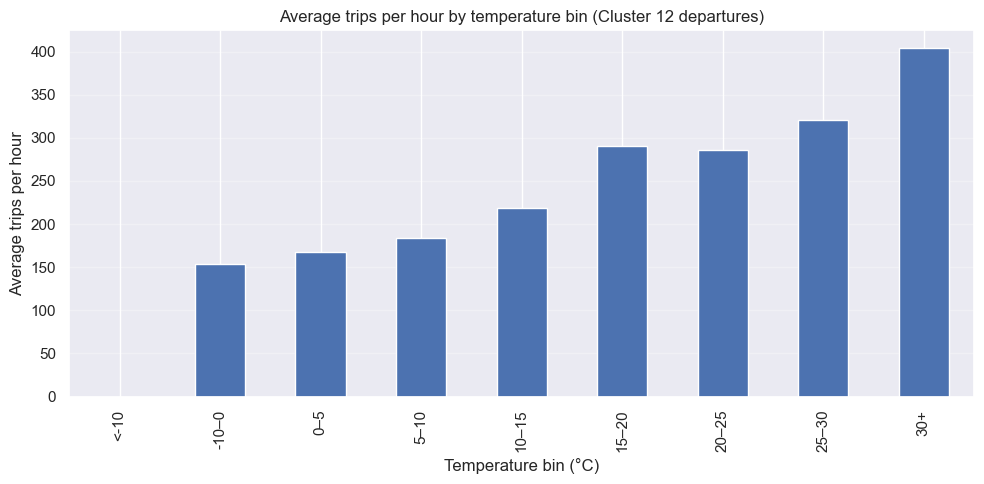

In [123]:
# Define temperature bins
bins = [-20, -10, 0, 5, 10, 15, 20, 25, 30, 40]
labels = ['<-10', '-10–0', '0–5', '5–10', '10–15', '15–20', '20–25', '25–30', '30+']

temp_bin = pd.cut(sample['temperature_2m (°C)'], bins=bins, labels=labels, include_lowest=True)
avg_trips_by_temp = sample.groupby(temp_bin)['trip_count'].mean()

plt.figure(figsize=(10,5))
avg_trips_by_temp.plot(kind='bar')
plt.xlabel('Temperature bin (°C)')
plt.ylabel('Average trips per hour')
plt.title('Average trips per hour by temperature bin (Cluster 12 departures)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


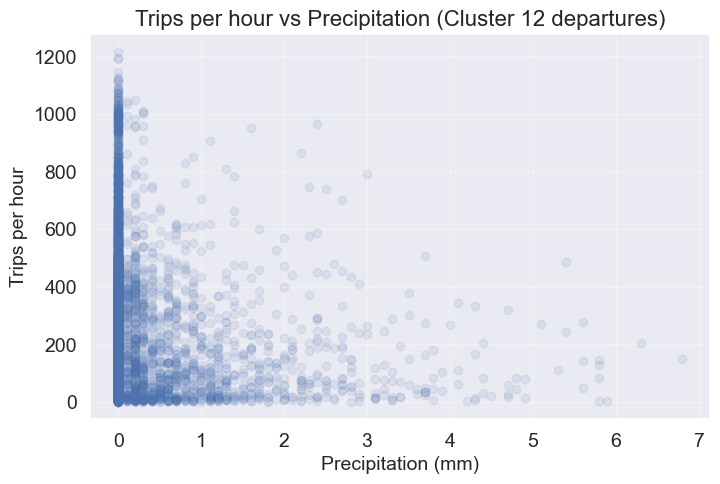

In [124]:
sample = grouped_rf_departures_weather[['trip_count', 'precipitation (mm)']].dropna()

plt.figure(figsize=(8,5))
plt.scatter(sample['precipitation (mm)'], sample['trip_count'], alpha=0.1)
plt.xlabel('Precipitation (mm)')
plt.ylabel('Trips per hour')
plt.title('Trips per hour vs Precipitation (Cluster 12 departures)')
simple_set_font_size(plt.gca(), labelsize=14, titlesize=16)
plt.grid(alpha=0.3)
plt.show()


/var/folders/2q/0s6yfy4s7cdcl3184vyy5v_w0000gp/T/ipykernel_8394/3255532719.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_trips_by_prec = sample.groupby(prec_bin)['trip_count'].mean()


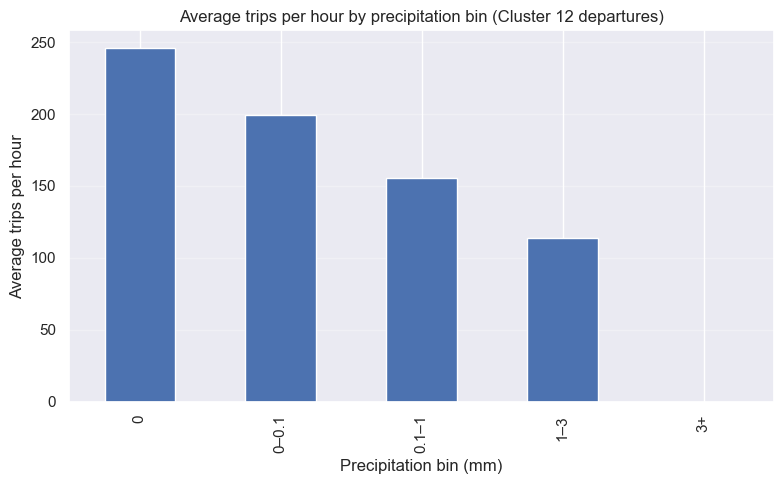

In [125]:
bins   = [0, 0.1, 1, 3, 10, 50]
labels = ['0', '0–0.1', '0.1–1', '1–3', '3+']

prec_bin = pd.cut(sample['precipitation (mm)'], bins=bins, labels=labels, include_lowest=True)
avg_trips_by_prec = sample.groupby(prec_bin)['trip_count'].mean()

plt.figure(figsize=(8,5))
avg_trips_by_prec.plot(kind='bar')
plt.xlabel('Precipitation bin (mm)')
plt.ylabel('Average trips per hour')
plt.title('Average trips per hour by precipitation bin (Cluster 12 departures)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Holidays as time series data

In [126]:
holidays = pd.read_csv('holidays.csv')
# All dates and hours for 2018
dates = pd.date_range('2018-01-01', '2018-12-31', freq='D', name='date')
hours = pd.Index(range(24), name='hour')

all_date_hour_2018 = (
    pd.MultiIndex.from_product([dates, hours], names=['date', 'hour'])
      .to_frame(index=False)
)

# Optional: combined datetime and index
all_date_hour_2018['datetime'] = all_date_hour_2018['date'] + pd.to_timedelta(all_date_hour_2018['hour'], unit='h')
all_date_hour_2018.set_index('datetime', inplace=True)
len(all_date_hour_2018)

8760

In [127]:
month_name_to_number = {'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
                               'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'}
holidays['Date'] = holidays['Date'].apply(lambda x: '2018-' + month_name_to_number[x[:3]] + '-' + x[4:].strip())
holidays['Date'] = pd.to_datetime(holidays['Date'], format='%Y-%m-%d')

holidays.set_index('Date', inplace=True)


In [128]:
holidays.drop(columns=['Day', 'Holiday Name', 'Comments'], inplace=True)

In [129]:
# One-hot encode Type on holidays without modifying the original dataframe
holidays_dummies = pd.get_dummies(holidays, columns=['Type'], prefix='type', dtype=int)
holidays_dummies.head()

,type_Federal Holiday,type_Government Holiday,type_Not A Public Holiday
Date,,,
2018-01-01,1,0,0
2018-01-15,1,0,0
2018-02-12,0,1,0
2018-02-19,1,0,0
2018-04-01,0,0,1


In [130]:
# Merge holidays_dummies with all_date_hour_2018
is_holiday = all_date_hour_2018.merge(
    holidays_dummies, 
    left_on='date', 
    right_index=True, 
    how='left'
)
len(is_holiday)

8760

In [131]:

# Fill NaN values with 0 for holiday type columns (non-holiday days)
holiday_cols = [col for col in is_holiday.columns if col.startswith('type_')]
is_holiday[holiday_cols] = is_holiday[holiday_cols].fillna(0).astype(int)

is_holiday.head()

,date,hour,type_Federal Holiday,type_Government Holiday,type_Not A Public Holiday
datetime,,,,,
2018-01-01 00:00:00,2018-01-01,0,1,0,0
2018-01-01 01:00:00,2018-01-01,1,1,0,0
2018-01-01 02:00:00,2018-01-01,2,1,0,0
2018-01-01 03:00:00,2018-01-01,3,1,0,0
2018-01-01 04:00:00,2018-01-01,4,1,0,0


In [132]:
is_holiday.drop(['date', 'hour'], axis=1, inplace=True)

In [133]:
is_holiday.iloc[356:363]

,type_Federal Holiday,type_Government Holiday,type_Not A Public Holiday
datetime,,,
2018-01-15 20:00:00,1,0,0
2018-01-15 21:00:00,1,0,0
2018-01-15 22:00:00,1,0,0
2018-01-15 23:00:00,1,0,0
2018-01-16 00:00:00,0,0,0
2018-01-16 01:00:00,0,0,0
2018-01-16 02:00:00,0,0,0


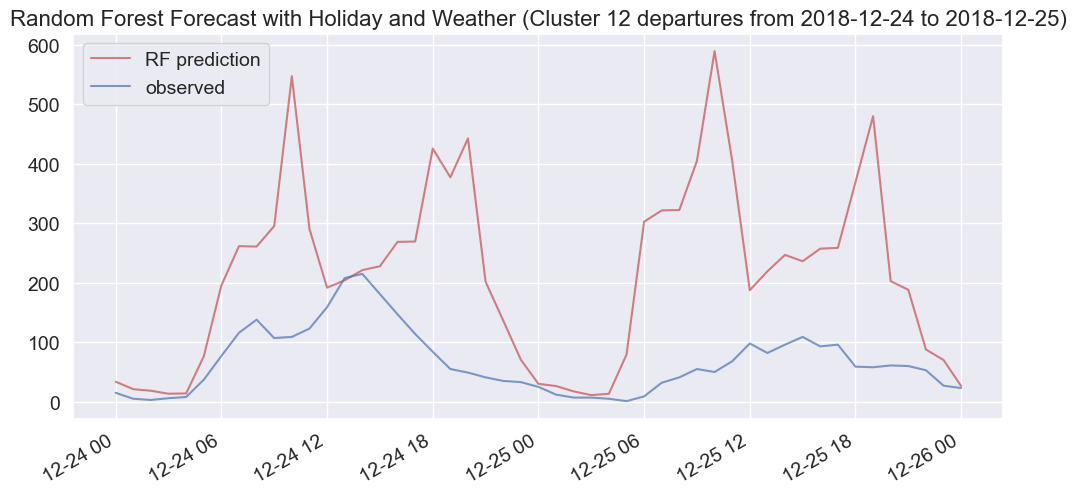

In [134]:
day_start, day_end = pd.Timestamp('2018-12-24'), pd.Timestamp('2018-12-25')
plotprediction(
    y_test_departures[day_start : day_end + pd.Timedelta('1D')],
    y_pred_rf_departures[(y_test_departures.index >= day_start) & (y_test_departures.index <= day_end + pd.Timedelta('1D'))],
    labels=['observed', 'RF prediction'], title=f"Random Forest Forecast with Holiday and Weather (Cluster 12 departures from {day_start.date()} to {day_end.date()})"
)

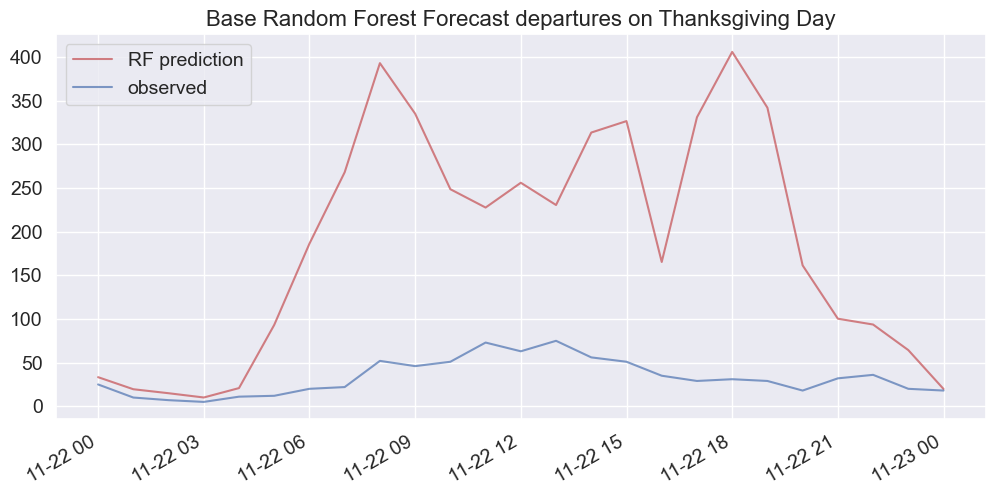

In [135]:
day_start, day_end = pd.Timestamp('2018-11-22'), pd.Timestamp('2018-11-22')
plotprediction(
    y_test_departures[day_start : day_end + pd.Timedelta('1D')],
    y_pred_rf_departures[(y_test_departures.index >= day_start) & (y_test_departures.index <= day_end + pd.Timedelta('1D'))],
    labels=['observed', 'RF prediction'], title=f"Base Random Forest Forecast departures on Thanksgiving Day"
)

## Adding the new information to the model

### Only the weather data

In [136]:
train_mask = grouped_rf_departures_weather.index < test_start
test_mask  = grouped_rf_departures_weather.index >= test_start


In [137]:
# All features except target and naive baseline
feature_cols_weather = [
    c for c in grouped_rf_departures_weather.columns
    if c not in ['trip_count', 'copy_pred']
]

X_train_w = grouped_rf_departures_weather.loc[train_mask, feature_cols_weather]
y_train_w = grouped_rf_departures_weather.loc[train_mask, 'trip_count']

# X_val_w   = grouped_rf_departures_weather.loc[val_mask, feature_cols_weather]
# y_val_w   = grouped_rf_departures_weather.loc[val_mask, 'trip_count']

X_test_w  = grouped_rf_departures_weather.loc[test_mask, feature_cols_weather]
y_test_w  = grouped_rf_departures_weather.loc[test_mask, 'trip_count']


In [138]:
rf_weather = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_weather.fit(X_train_w, y_train_w)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
y_train_pred_w = rf_weather.predict(X_train_w)
# y_val_pred_w   = rf_weather.predict(X_val_w)
y_test_pred_w  = rf_weather.predict(X_test_w)

print_stats(y_train_w, y_train_pred_w, "TRAIN (with weather)")
# print_stats(y_val_w,   y_val_pred_w,   "VALIDATION (with weather)")
print_stats(y_test_w,  y_test_pred_w,  "TEST (with weather)")


TRAIN (with weather): 
	r^2=0.981164
	MSE=953.043455
	MAE=17.356164
	MAPE=17.176340
TEST (with weather): 
	r^2=0.770977
	MSE=7404.224458
	MAE=50.156011
	MAPE=75.669640


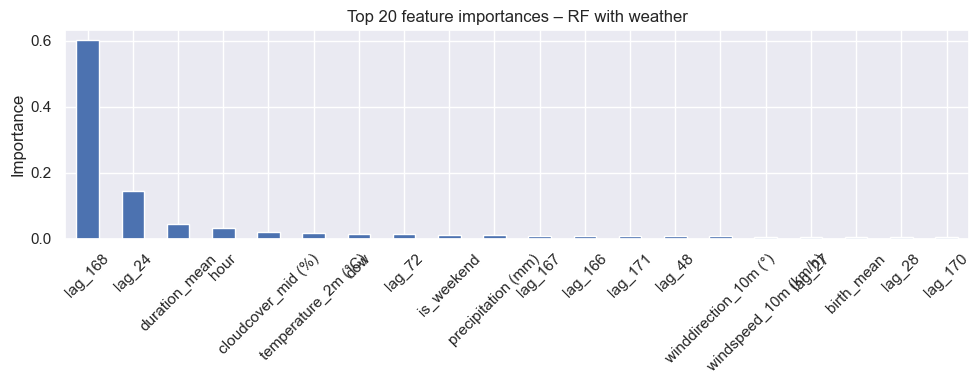

temperature_2m (°C)    0.015857
precipitation (mm)     0.009449
dtype: float64


In [140]:
importances_w = pd.Series(rf_weather.feature_importances_, index=feature_cols_weather)
imp_top_w = importances_w.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top_w.plot(kind='bar')
plt.title("Top 20 feature importances – RF with weather")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(importances_w[['temperature_2m (°C)', 'precipitation (mm)']])


### Only add Holiday data

In [141]:
# Merge holiday indicators on datetime index
grouped_rf_holiday = grouped_rf_departures.merge(
    is_holiday,
    how='left',
    left_index=True,
    right_index=True
)
feature_cols = [
    c for c in grouped_rf_holiday.columns
    if c not in ['trip_count']
]

X_train_holiday = grouped_rf_holiday.loc[train_mask, feature_cols]
y_train_holiday      = grouped_rf_holiday.loc[train_mask, 'trip_count']

X_test_holiday  = grouped_rf_holiday.loc[test_mask, feature_cols]
y_test_holiday       = grouped_rf_holiday.loc[test_mask, 'trip_count']

rf_holiday = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_holiday.fit(X_train_holiday, y_train_holiday)

y_train_pred_holiday = rf_holiday.predict(X_train_holiday)
# y_val_pred_holiday   = rf_holiday.predict(X_val_holiday)
y_test_pred_holiday  = rf_holiday.predict(X_test_holiday)
print_stats(y_train_holiday, y_train_pred_holiday, "TRAIN – RF with holiday")
# print_stats(y_val,   y_val_pred_holiday,   "VALIDATION – RF with holiday")
print_stats(y_test_holiday,  y_test_pred_holiday,  "TEST – RF with holiday")

TRAIN – RF with holiday: 
	r^2=0.977700
	MSE=1128.316642
	MAE=18.770503
	MAPE=19.341032
TEST – RF with holiday: 
	r^2=0.719949
	MSE=9053.933726
	MAE=55.481975
	MAPE=87.550729


We reduced our training error but increased our test error a little bit, so it does seem like the added data of holidays contribute to overfitting instead of helping it generalize to new data. But this is also to be expected. The data set of holidays in New York only had 18 distinct holidays, whereas the weather data had an impact on a lot more days and hours than holidays did.

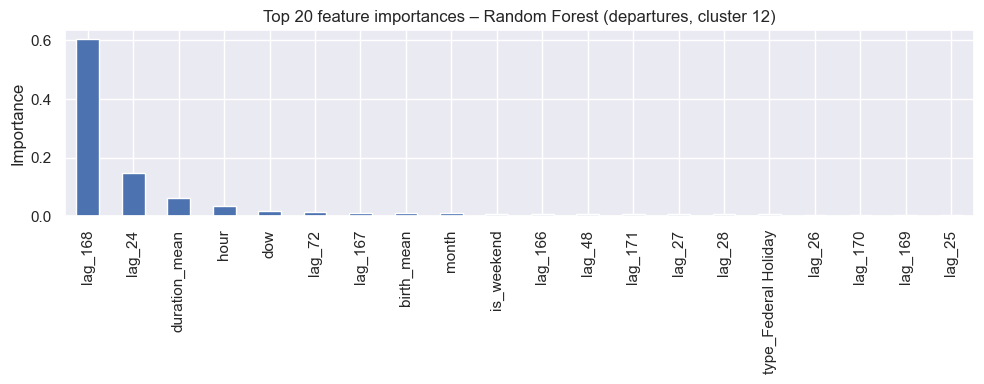

type_Federal Holiday         0.007929
type_Government Holiday      0.000068
type_Not A Public Holiday    0.000236
dtype: float64


In [142]:
importances = pd.Series(rf_holiday.feature_importances_, index=feature_cols)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (departures, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['type_Federal Holiday', 'type_Government Holiday', 'type_Not A Public Holiday']])

### Both data at the same time

In [143]:
# Merge holiday indicators on datetime index
grouped_rf_h_w = grouped_rf_departures_weather.merge(
    is_holiday,
    how='left',
    left_index=True,
    right_index=True
)
feature_cols = [
    c for c in grouped_rf_h_w.columns
    if c not in ['trip_count']
]
feature_cols

['is_weekend',
 'duration_mean',
 'birth_mean',
 'lag_24',
 'lag_25',
 'lag_26',
 'lag_27',
 'lag_28',
 'lag_48',
 'lag_72',
 'lag_166',
 'lag_167',
 'lag_168',
 'lag_169',
 'lag_170',
 'lag_171',
 'hour',
 'dow',
 'month',
 'most_common_user_type_Subscriber',
 'most_common_gender_1',
 'most_common_gender_2',
 'temperature_2m (°C)',
 'precipitation (mm)',
 'rain (mm)',
 'cloudcover (%)',
 'cloudcover_low (%)',
 'cloudcover_mid (%)',
 'cloudcover_high (%)',
 'windspeed_10m (km/h)',
 'winddirection_10m (°)',
 'type_Federal Holiday',
 'type_Government Holiday',
 'type_Not A Public Holiday']

In [144]:
x_train_w_h = grouped_rf_h_w.loc[train_mask, feature_cols]
y_train_w_h      = grouped_rf_h_w.loc[train_mask, 'trip_count']

x_test_w_h  = grouped_rf_h_w.loc[test_mask, feature_cols]
y_test_w_h       = grouped_rf_h_w.loc[test_mask, 'trip_count']

rf_w_h = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    min_samples_split=5
)
rf_w_h.fit(x_train_w_h, y_train_w_h)

y_train_pred_w_h = rf_w_h.predict(x_train_w_h)
# y_val_pred_holiday   = rf_w_h.predict(x_val_w_h)
y_test_pred_w_h  = rf_w_h.predict(x_test_w_h)
print_stats(y_train_w_h, y_train_pred_w_h, "TRAIN – RF with holiday and weather")
# print_stats(y_val,   y_val_pred_holiday,   "VALIDATION – RF with holiday and weather")
print_stats(y_test_w_h,  y_test_pred_w_h,  "TEST – RF with holiday and weather")

TRAIN – RF with holiday and weather: 
	r^2=0.980479
	MSE=987.689536
	MAE=17.753816
	MAPE=17.688808
TEST – RF with holiday and weather: 
	r^2=0.771023
	MSE=7402.711596
	MAE=49.876627
	MAPE=74.691302


So this model clearly performs worse than just using the weather data. The complexity is now to big, and the low amount of affected days with holidays just does not make it worth it to add the model directly.

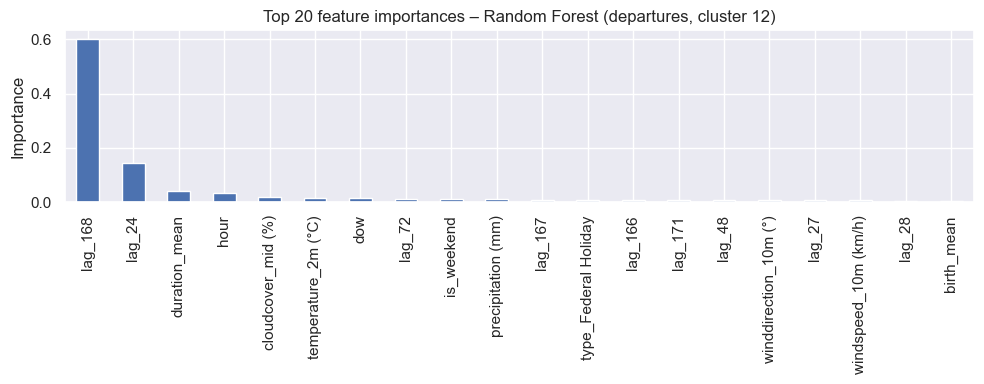

type_Federal Holiday    0.00769
dtype: float64


In [145]:
importances = pd.Series(rf_w_h.feature_importances_, index=feature_cols)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (departures, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['type_Federal Holiday']])

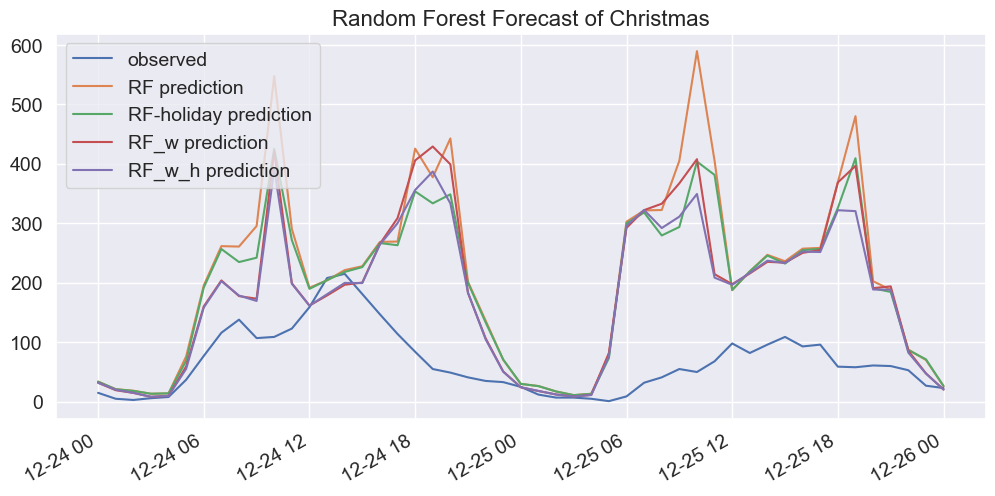

In [175]:
day_start, day_end = pd.Timestamp('2018-12-24'), pd.Timestamp('2018-12-25')
old_pred = rf.predict(X_test_departures)
labels = ['observed', 'RF prediction', 'RF-holiday prediction', 'RF_w prediction', 'RF_w_h prediction']
plotprediction(
    y_test_w_h[day_start : day_end + pd.Timedelta('1D')],
    [
        old_pred[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_holiday[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w_h[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))]
    ],
labels=labels, title=f"Random Forest Forecast of Christmas"
)

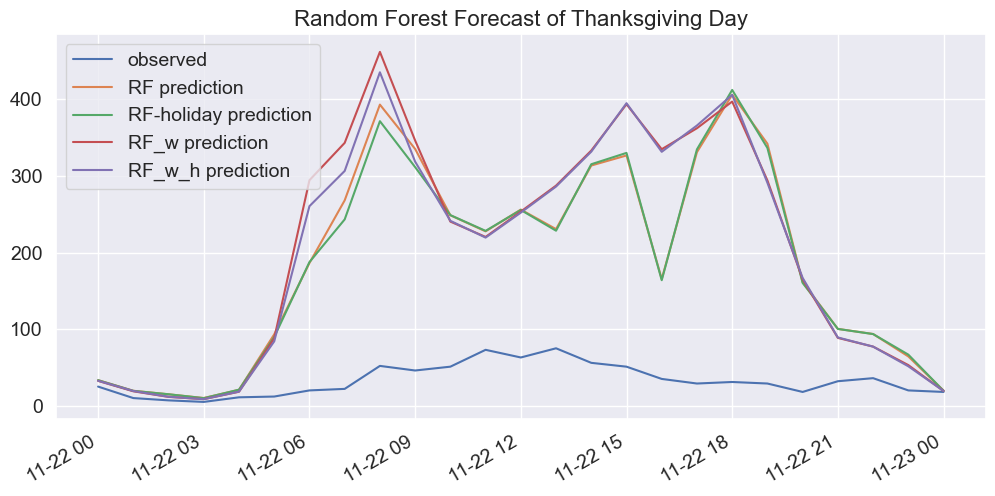

In [174]:
day_start, day_end = pd.Timestamp('2018-11-22'), pd.Timestamp('2018-11-22')

plotprediction(
    y_test_w_h[day_start : day_end + pd.Timedelta('1D')],
    [
        old_pred[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_holiday[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w_h[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))]
    ],
    labels=labels, 
    title=f"Random Forest Forecast of Thanksgiving Day"
)

# PCA Decomposition

## On Covariance matrix

In [149]:
from sklearn.decomposition import PCA
# Define features and target
features = grouped_rf_departures.drop(columns=['trip_count'])
target = grouped_rf_departures['trip_count']
# Split into training and testing sets
X_train = features[train_mask]
y_train = target[train_mask]
X_test = features[test_mask]
y_test = target[test_mask]
# Initialize and fit PCA
pca = PCA()  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train)

In [150]:
X_test_pca = pca.transform(X_test)

# Check the shape of the transformed data
X_train_pca.shape, X_test_pca.shape

((7088, 22), (1462, 22))

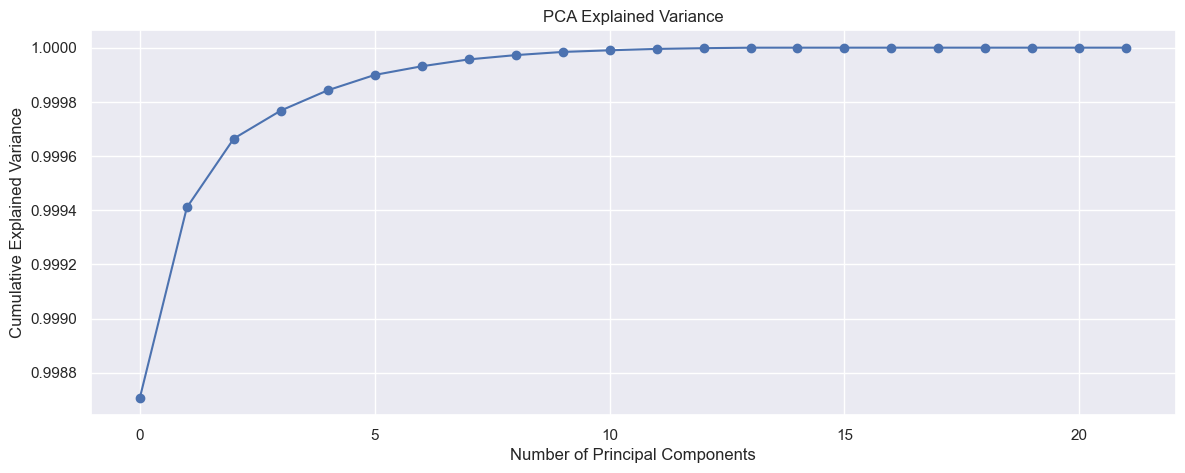

In [151]:
plt.plot(pca.explained_variance_ratio_.cumsum(), '-ob')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

## On Correlation Matrix

In [178]:
# Define features and target
features = grouped_rf_departures.drop(columns=['trip_count'])
target = grouped_rf_departures['trip_count']
# Split into training and testing sets
features = (features - features.mean()) / features.std()
X_train = features[train_mask]
y_train = target[train_mask]
X_test = features[test_mask]
y_test = target[test_mask]
# Initialize and fit PCA
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_train_pca = pca.fit_transform(X_train)

In [179]:
X_test_pca = pca.transform(X_test)

# Check the shape of the transformed data
X_train_pca.shape, X_test_pca.shape

((7088, 13), (1462, 13))

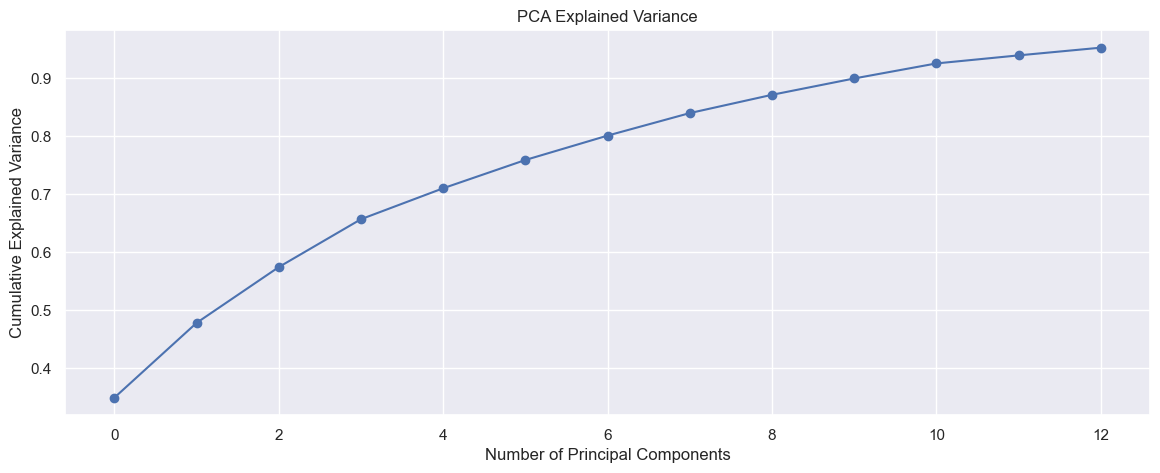

In [180]:
plt.plot(pca.explained_variance_ratio_.cumsum(), '-ob')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

In [181]:
len(pca.components_)

13

In [182]:
rf_pca = RandomForestRegressor(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [183]:
y_train_pred = rf_pca.predict(X_train_pca)
y_test_pred  = rf_pca.predict(X_test_pca)

print_stats(y_train, y_train_pred, "TRAIN")
print_stats(y_test,  y_test_pred,  "TEST")


TRAIN: 
	r^2=0.843095
	MSE=7938.929468
	MAE=56.889264
	MAPE=71.454370
TEST: 
	r^2=0.544733
	MSE=14718.567093
	MAE=75.716893
	MAPE=111.117540


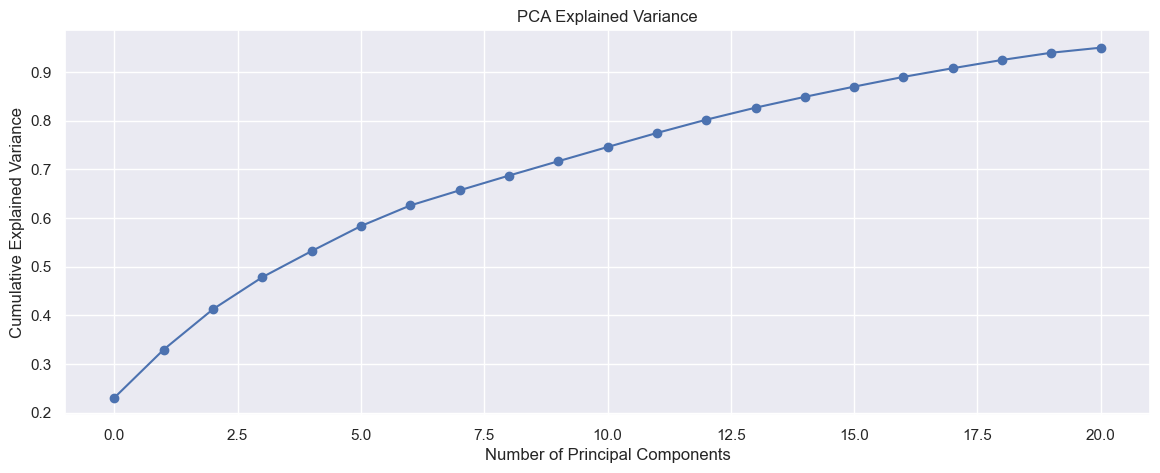

In [201]:
pca = PCA(n_components=0.95)  # Retain 95% of variance
x_train_w_h_stds = (x_train_w_h - x_train_w_h.mean()) / x_train_w_h.std()
# x_val_w_h_stds = (x_val_w_h - x_train_w_h.mean()) / x_train_w_h.std()
x_test_w_h_stds = (x_test_w_h - x_train_w_h.mean()) / x_train_w_h.std()
X_train_pca = pca.fit_transform(x_train_w_h_stds)
# X_val_pca = pca.transform(x_val_w_h_stds)
X_test_pca = pca.transform(x_test_w_h_stds)

plt.plot(pca.explained_variance_ratio_.cumsum(), '-ob')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

In [202]:
rf_w_h_pca = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_w_h_pca.fit(X_train_pca, y_train)
y_train_pred_pca = rf_w_h_pca.predict(X_train_pca)
# y_val_pred_pca = rf_w_h_pca.predict(X_val_pca)
y_test_pred_pca  = rf_w_h_pca.predict(X_test_pca)
print_stats(y_train, y_train_pred_pca, "TRAIN – RF with holiday, weather and PCA")
# print_stats(y_val,  y_val_pred_pca,  "VAL – RF with holiday, weather and PCA")
print_stats(y_test,  y_test_pred_pca,  "TEST – RF with holiday, weather and PCA")

TRAIN – RF with holiday, weather and PCA: 
	r^2=0.972487
	MSE=1392.054676
	MAE=21.953889
	MAPE=27.389962
TEST – RF with holiday, weather and PCA: 
	r^2=0.674731
	MSE=10515.800580
	MAE=68.307567
	MAPE=107.404470


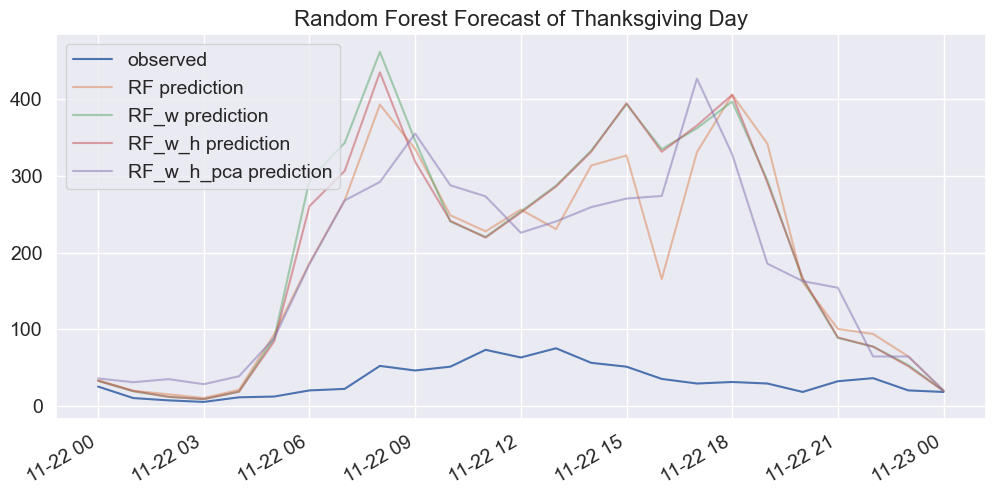

In [203]:
day_start, day_end = pd.Timestamp('2018-11-22'), pd.Timestamp('2018-11-22')
labels = ['observed', 'RF prediction', 'RF_w prediction', 'RF_w_h prediction', 'RF_w_h_pca prediction']
plotprediction(
    y_test_w_h[day_start : day_end + pd.Timedelta('1D')],
    [
        old_pred[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w_h[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_pca[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))]
    ],
    labels=labels, 
    title=f"Random Forest Forecast of Thanksgiving Day"
)

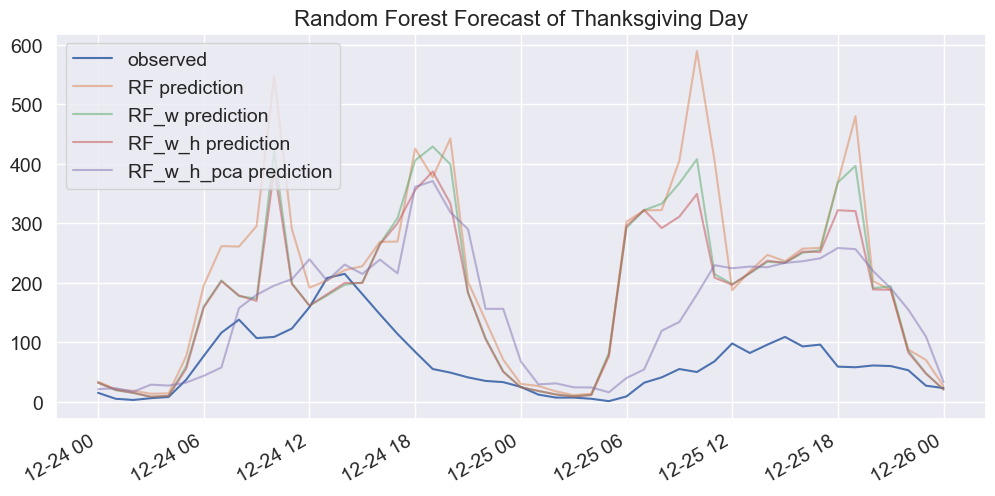

In [204]:
day_start, day_end = pd.Timestamp('2018-12-24'), pd.Timestamp('2018-12-25')
labels = ['observed', 'RF prediction', 'RF_w prediction', 'RF_w_h prediction', 'RF_w_h_pca prediction']
plotprediction(
    y_test_w_h[day_start : day_end + pd.Timedelta('1D')],
    [
        old_pred[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_w_h[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))],
        y_test_pred_pca[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))]
    ],
    labels=labels, 
    title=f"Random Forest Forecast of Thanksgiving Day"
)

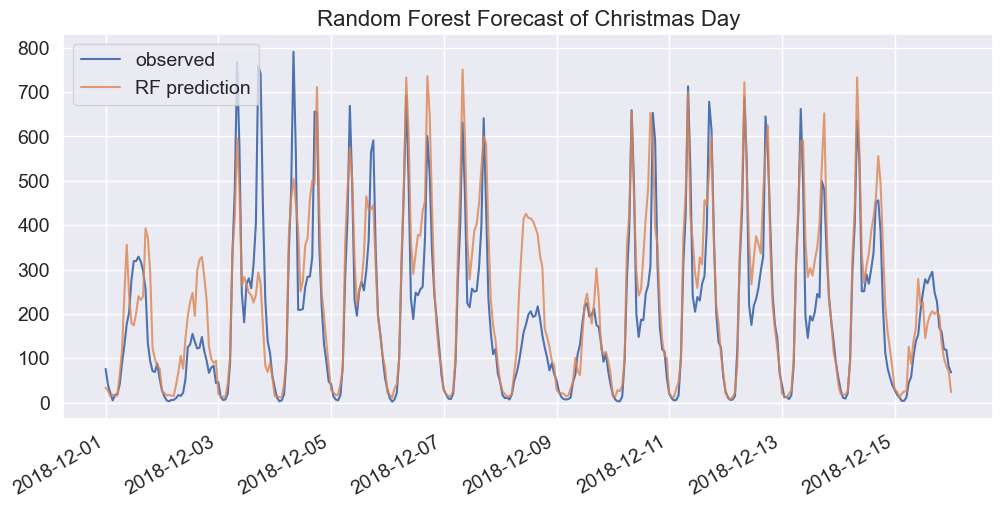

In [200]:
day_start, day_end = pd.Timestamp('2018-12-01'), pd.Timestamp('2018-12-15')
labels = ['observed', 'RF prediction', 'RF_w prediction', 'RF_w_h_pca prediction']
plotprediction(
    y_test_w_h[day_start : day_end + pd.Timedelta('1D')],
    [
        y_test_pred_pca[(y_test_w_h.index >= day_start) & (y_test_w_h.index <= day_end + pd.Timedelta('1D'))]
    ],
    labels=labels, alpha=0.8,
    title=f"Random Forest Forecast of Christmas Day"
)